# 03 — Preprocessing & Exploratory Data Analysis

## ANTARBODH — AI-Powered Subsurface Ocean Intelligence

This notebook performs exploratory data analysis, quality control,
preprocessing, spatial/temporal harmonization, and preparation of
model-ready input and target datasets.

### Workflow

1. Load audited raw datasets
2. Statistical EDA
3. Distribution analysis
4. Outlier and extreme-value analysis
5. Spatial EDA
6. Missing-value analysis
7. SSS ascending/descending analysis
8. GLORYS depth-wise analysis
9. Multi-variable relationship analysis
10. Temporal EDA
11. Coordinate and time normalization
12. Unit conversion and invalid-value handling
13. Quality control and masking
14. Missing-data treatment
15. Regridding and interpolation
16. Dataset alignment
17. Model-ready X/Y construction
18. Normalization
19. Final QC and leakage checks
20. Save processed data and reports

In [170]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [171]:

# Project root
PROJECT_ROOT = Path("..")

# Raw data
RAW_DIR = PROJECT_ROOT / "data" / "raw"

GLORYS_DIR = RAW_DIR / "glorys"
SST_DIR = RAW_DIR / "sst"
SSS_DIR = RAW_DIR / "sss"
SSH_DIR = RAW_DIR / "ssh"
CURRENTS_DIR = RAW_DIR / "currents"
WINDS_DIR = RAW_DIR / "winds"
ARGO_DIR = RAW_DIR / "argo"

# Output directories
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
REPORTS_DIR = OUTPUT_DIR / "reports"
STATS_DIR = OUTPUT_DIR / "statistics"

# Create output directories if they do not exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Raw data:", RAW_DIR.resolve())
print("Outputs:", OUTPUT_DIR.resolve())

Project root: /Volumes/SAM-T7/SIH/Antarbodh-demo
Raw data: /Volumes/SAM-T7/SIH/Antarbodh-demo/data/raw
Outputs: /Volumes/SAM-T7/SIH/Antarbodh-demo/outputs


In [239]:
glorys = xr.open_dataset(
    GLORYS_DIR / "glorys_bob_(1).nc"
)

sst = xr.open_dataset(
    SST_DIR / "sst_bob_(1).nc"
)

sss_asc = xr.open_dataset(
    SSS_DIR / "sss_bob_ascending_(1).nc"
)

sss_desc = xr.open_dataset(
    SSS_DIR / "sss_bob_descending_(1).nc"
)

ssh = xr.open_dataset(
    SSH_DIR / "ssh_bob_(1).nc"
)

currents = xr.open_dataset(
    CURRENTS_DIR / "currents_bob_(1).nc"
)

winds = xr.open_dataset(
    WINDS_DIR / "winds_bob_(1).nc"
)

In [173]:
datasets = {
    "GLORYS": glorys,
    "SST": sst,
    "SSS Ascending": sss_asc,
    "SSS Descending": sss_desc,
    "SSH": ssh,
    "Currents": currents,
    "Winds": winds,
}

for name, ds in datasets.items():
    print(f"{name}:")
    print(ds)
    print("-" * 80)

GLORYS:
<xarray.Dataset> Size: 389MB
Dimensions:    (time: 31, depth: 36, latitude: 181, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * depth      (depth) float32 144B 0.494 1.541 2.646 ... 763.3 902.3 1.062e+03
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 80.0 80.08 80.17 ... 99.83 99.92 100.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 389MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Globa

In [174]:
for name, ds in datasets.items():
    print(f"{name}: {list(ds.data_vars)}")

GLORYS: ['thetao']
SST: ['sea_surface_temperature']
SSS Ascending: ['Sea_Surface_Salinity']
SSS Descending: ['Sea_Surface_Salinity']
SSH: ['sla']
Currents: ['uo', 'vo']
Winds: ['eastward_wind', 'northward_wind']


In [175]:
for name, ds in datasets.items():
    if "time" in ds.coords:
        print(
            f"{name}:",
            ds["time"].values
        )

GLORYS: ['2020-01-01T00:00:00.000000000' '2020-01-02T00:00:00.000000000'
 '2020-01-03T00:00:00.000000000' '2020-01-04T00:00:00.000000000'
 '2020-01-05T00:00:00.000000000' '2020-01-06T00:00:00.000000000'
 '2020-01-07T00:00:00.000000000' '2020-01-08T00:00:00.000000000'
 '2020-01-09T00:00:00.000000000' '2020-01-10T00:00:00.000000000'
 '2020-01-11T00:00:00.000000000' '2020-01-12T00:00:00.000000000'
 '2020-01-13T00:00:00.000000000' '2020-01-14T00:00:00.000000000'
 '2020-01-15T00:00:00.000000000' '2020-01-16T00:00:00.000000000'
 '2020-01-17T00:00:00.000000000' '2020-01-18T00:00:00.000000000'
 '2020-01-19T00:00:00.000000000' '2020-01-20T00:00:00.000000000'
 '2020-01-21T00:00:00.000000000' '2020-01-22T00:00:00.000000000'
 '2020-01-23T00:00:00.000000000' '2020-01-24T00:00:00.000000000'
 '2020-01-25T00:00:00.000000000' '2020-01-26T00:00:00.000000000'
 '2020-01-27T00:00:00.000000000' '2020-01-28T00:00:00.000000000'
 '2020-01-29T00:00:00.000000000' '2020-01-30T00:00:00.000000000'
 '2020-01-31T00:0

In [176]:
for name, ds in datasets.items():
    print(f"{name}: {dict(ds.sizes)}")

GLORYS: {'time': 31, 'depth': 36, 'latitude': 181, 'longitude': 241}
SST: {'time': 31, 'latitude': 150, 'longitude': 200}
SSS Ascending: {'time': 31, 'latitude': 75, 'longitude': 100}
SSS Descending: {'time': 31, 'latitude': 75, 'longitude': 100}
SSH: {'time': 31, 'latitude': 60, 'longitude': 80}
Currents: {'time': 31, 'depth': 1, 'latitude': 60, 'longitude': 80}
Winds: {'time': 31, 'latitude': 60, 'longitude': 80}


## 2. Statistical EDA

The objective of this section is to characterize the statistical
properties of the raw variables before applying any preprocessing.

We examine:
- central tendency
- spread
- quantiles
- minimum and maximum values
- missing values
- potential extreme values

No values are modified during this stage.

In [177]:
# Variables used in the ANTARBODH prototype

eda_variables = {
    "SST": sst["sea_surface_temperature"],
    "SSS Ascending": sss_asc["Sea_Surface_Salinity"],
    "SSS Descending": sss_desc["Sea_Surface_Salinity"],
    "SSH": ssh["sla"],
    "Current U": currents["uo"],
    "Current V": currents["vo"],
    "Wind U": winds["eastward_wind"],
    "Wind V": winds["northward_wind"],
    "GLORYS Temperature": glorys["thetao"],
}

print(f"Number of variables: {len(eda_variables)}")

for name, da in eda_variables.items():
    print(f"{name:25s} -> {da.dims}")

Number of variables: 9
SST                       -> ('time', 'latitude', 'longitude')
SSS Ascending             -> ('time', 'latitude', 'longitude')
SSS Descending            -> ('time', 'latitude', 'longitude')
SSH                       -> ('time', 'latitude', 'longitude')
Current U                 -> ('time', 'depth', 'latitude', 'longitude')
Current V                 -> ('time', 'depth', 'latitude', 'longitude')
Wind U                    -> ('time', 'latitude', 'longitude')
Wind V                    -> ('time', 'latitude', 'longitude')
GLORYS Temperature        -> ('time', 'depth', 'latitude', 'longitude')


In [178]:
#Descriptive statistics for each variable

stats={}

for name,da in eda_variables.items():
    values=da.values #total values in the da
    valid_values=values[np.isfinite(values)] #total no. of valid values in the da
    stats[name] = {
        "valid_count": valid_values.size,
        "missing_count": np.isnan(values).sum(),
        "missing_percent": np.isnan(values).mean() * 100,
        "min": np.min(valid_values),
        "q25": np.percentile(valid_values, 25),
        "median": np.median(valid_values),
        "mean": np.mean(valid_values),
        "q75": np.percentile(valid_values, 75),
        "max": np.max(valid_values),
        "std": np.std(valid_values),
    }

stats


{'SST': {'valid_count': 560671,
  'missing_count': np.int64(369329),
  'missing_percent': np.float64(39.71279569892473),
  'min': np.float64(295.17999999999995),
  'q25': np.float64(300.08),
  'median': np.float64(301.0),
  'mean': np.float64(300.6735444494186),
  'q75': np.float64(301.44),
  'max': np.float64(304.07),
  'std': np.float64(1.085411835903849)},
 'SSS Ascending': {'valid_count': 21275,
  'missing_count': np.int64(211225),
  'missing_percent': np.float64(90.84946236559139),
  'min': np.float32(17.784006),
  'q25': np.float32(31.462955),
  'median': np.float32(32.526848),
  'mean': np.float32(32.301655),
  'q75': np.float32(33.33932),
  'max': np.float32(40.67075),
  'std': np.float32(1.565392)},
 'SSS Descending': {'valid_count': 42775,
  'missing_count': np.int64(189725),
  'missing_percent': np.float64(81.60215053763442),
  'min': np.float32(18.2961),
  'q25': np.float32(31.52076),
  'median': np.float32(32.637844),
  'mean': np.float32(32.39086),
  'q75': np.float32(33.

In [179]:
for name, values in stats.items():
    print(f"\n{name}")
    print("-" * len(name))

    for statistic, value in values.items():
        if "count" in statistic:
            print(f"{statistic:18s}: {value}")
        else:
            print(f"{statistic:18s}: {value:.4f}")


SST
---
valid_count       : 560671
missing_count     : 369329
missing_percent   : 39.7128
min               : 295.1800
q25               : 300.0800
median            : 301.0000
mean              : 300.6735
q75               : 301.4400
max               : 304.0700
std               : 1.0854

SSS Ascending
-------------
valid_count       : 21275
missing_count     : 211225
missing_percent   : 90.8495
min               : 17.7840
q25               : 31.4630
median            : 32.5268
mean              : 32.3017
q75               : 33.3393
max               : 40.6707
std               : 1.5654

SSS Descending
--------------
valid_count       : 42775
missing_count     : 189725
missing_percent   : 81.6022
min               : 18.2961
q25               : 31.5208
median            : 32.6378
mean              : 32.3909
q75               : 33.4109
max               : 41.6270
std               : 1.5372

SSH
---
valid_count       : 125147
missing_count     : 23653
missing_percent   : 15.8958
min   

In [180]:
stats_file = STATS_DIR / "raw_statistical_eda_1_month.txt"

with open(stats_file, "w") as f:
    f.write("ANTARBODH — Raw Statistical EDA\n")
    f.write("=" * 50 + "\n\n")

    for name, values in stats.items():
        f.write(f"{name}\n")
        f.write("-" * len(name) + "\n")

        for statistic, value in values.items():
            f.write(f"{statistic}: {value}\n")

        f.write("\n")

print(f"Saved statistics to: {stats_file}")

Saved statistics to: ../outputs/statistics/raw_statistical_eda_1_month.txt


In [181]:
print("SST units:", sst["sea_surface_temperature"].attrs.get("units"))
print("SST standard name:", sst["sea_surface_temperature"].attrs.get("standard_name"))

SST units: kelvin
SST standard name: sea_surface_foundation_temperature


### Distribution Analysis

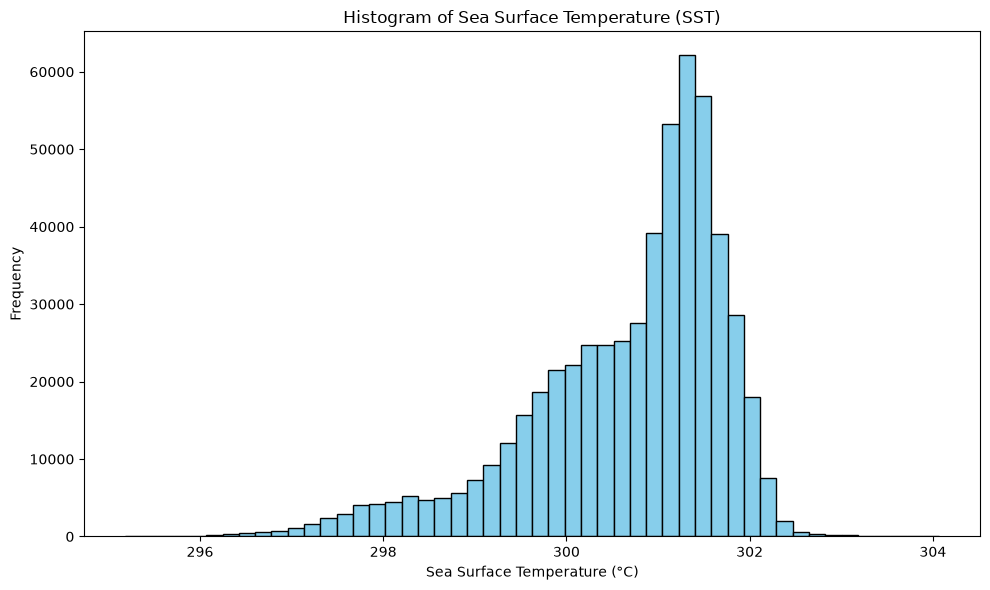

In [182]:
##SST

sst_values= sst["sea_surface_temperature"].values
sst_values=sst_values[np.isfinite(sst_values)] #filtering out invalid values

plt.figure(figsize=(10,6))

plt.hist(sst_values, bins=50, color='skyblue', edgecolor='black')

plt.xlabel("Sea Surface Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Histogram of Sea Surface Temperature (SST)")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "sst_distribution_raw.png",dpi=150,bbox_inches='tight')  

plt.show()

SST
* No obvious pathological values are visible.
* The distribution is not symmetric; it has a noticeable cooler tail.
* The raw values are in Kelvin, so the later preprocessing step will convert them to °C.
* The distribution itself does not justify removing extreme values.
* The major issue with SST remains its high missingness, which we need to investigate spatially.

Conclusion: 🟢 Values look reasonable; investigate missing-data pattern.

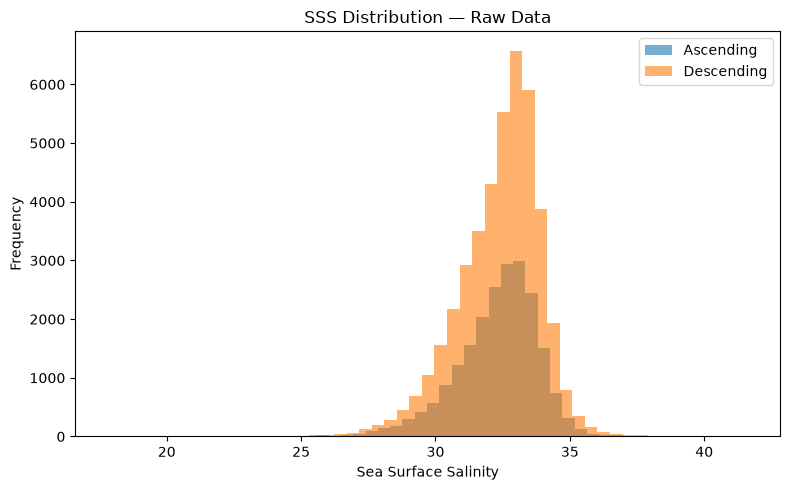

In [183]:
sss_asc_values = sss_asc["Sea_Surface_Salinity"].values
sss_asc_values = sss_asc_values[np.isfinite(sss_asc_values)]

sss_desc_values = sss_desc["Sea_Surface_Salinity"].values
sss_desc_values = sss_desc_values[np.isfinite(sss_desc_values)]

plt.figure(figsize=(8, 5))

plt.hist(sss_asc_values, bins=50, alpha=0.6, label="Ascending")
plt.hist(sss_desc_values, bins=50, alpha=0.6, label="Descending")

plt.xlabel("Sea Surface Salinity")
plt.ylabel("Frequency")
plt.title("SSS Distribution — Raw Data")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* Ascending and descending SSS do not have identical statistical behavior.
* The ascending product contains potentially suspicious high-salinity observations.
* However, the graph alone does not prove that those values are erroneous.
* We should investigate where those high values occur geographically and whether they occur in isolated pixels or coherent regions.
* The two datasets should therefore not simply be blindly averaged yet.

Conclusion: 🔴 Requires dedicated SSS QC/outlier investigation.

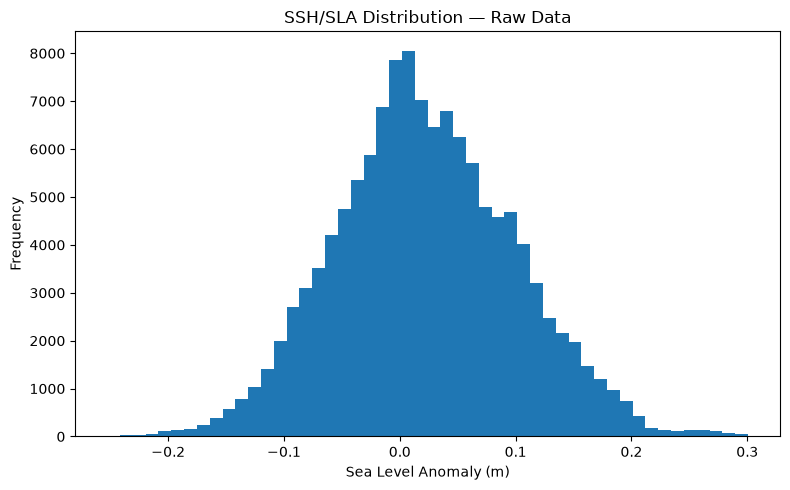

In [184]:
ssh_values = ssh["sla"].values
ssh_values = ssh_values[np.isfinite(ssh_values)]

plt.figure(figsize=(8, 5))

plt.hist(ssh_values, bins=50)

plt.xlabel("Sea Level Anomaly (m)")
plt.ylabel("Frequency")
plt.title("SSH/SLA Distribution — Raw Data")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ssh_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* The distribution is broadly centered around zero.
* Positive and negative anomalies are expected for SLA.
* No obvious pathological spike or impossible-looking distribution is visible.
* The slight positive skew is not itself a problem.

Conclusion: 🟢 No immediate anomaly; retain for further spatial/QC analysis.

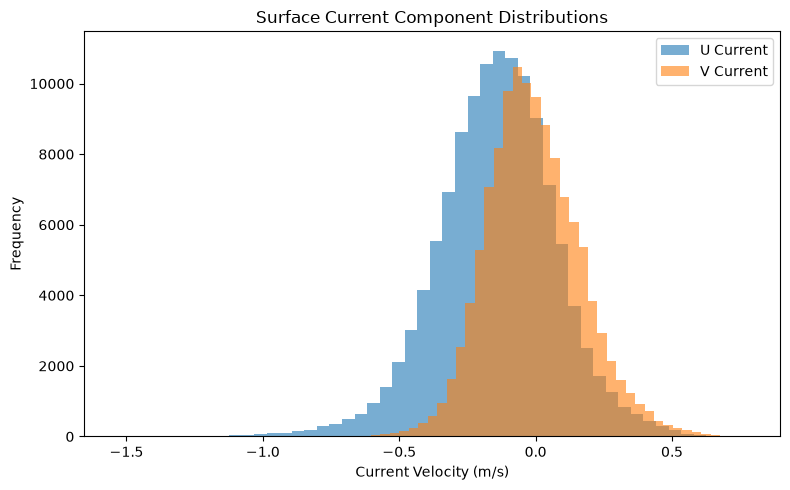

In [185]:
uo_values = currents["uo"].values
uo_values = uo_values[np.isfinite(uo_values)]

vo_values = currents["vo"].values
vo_values = vo_values[np.isfinite(vo_values)]

plt.figure(figsize=(8, 5))

plt.hist(uo_values, bins=50, alpha=0.6, label="U Current")
plt.hist(vo_values, bins=50, alpha=0.6, label="V Current")

plt.xlabel("Current Velocity (m/s)")
plt.ylabel("Frequency")
plt.title("Surface Current Component Distributions")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* The distributions look continuous rather than containing obvious isolated numerical spikes.
* The tails should nevertheless be checked spatially.
* We should not remove negative values.
* We should eventually consider current speed as an additional diagnostic:
$$ Speed = \sqrt{U^2 + V^2} $$

* but we don't necessarily need to make speed a model input because our planned input channels remain U/V.

Conclusion: 🟢 No obvious anomaly; perform physical/extreme-value QC later.

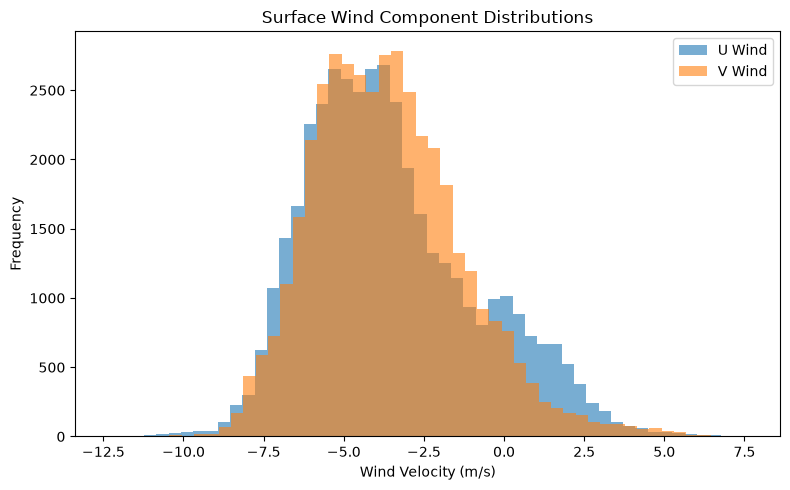

In [186]:
wind_u_values = winds["eastward_wind"].values
wind_u_values = wind_u_values[np.isfinite(wind_u_values)]

wind_v_values = winds["northward_wind"].values
wind_v_values = wind_v_values[np.isfinite(wind_v_values)]

plt.figure(figsize=(8, 5))

plt.hist(wind_u_values, bins=50, alpha=0.6, label="U Wind")
plt.hist(wind_v_values, bins=50, alpha=0.6, label="V Wind")

plt.xlabel("Wind Velocity (m/s)")
plt.ylabel("Frequency")
plt.title("Surface Wind Component Distributions")
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_distribution_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Inference:

* Values themselves don't immediately look like impossible numerical values.
* The strong asymmetry is worth investigating.
* The much bigger concern is the 72.4% missingness.
* The spatial pattern of the available observations is therefore critical.
* We should investigate whether the missing values follow the ASCAT swath pattern.

Conclusion: 🟡 Values require some investigation, but missingness/swath coverage is the bigger issue.

### Distribution EDA — Initial Inference

The raw-variable distributions provide several important observations.

1. SST shows a broad but physically plausible distribution. No obvious
   pathological values are evident, although its high missing-data
   fraction requires spatial investigation.

2. SSS shows substantially different distributions between ascending
   and descending observations. The ascending product has a broader
   distribution and a pronounced high-salinity tail reaching ~40–41.
   These values should not be removed automatically and require
   spatial and overlap-based QC.

3. SSH/SLA is approximately centered around zero with a reasonable
   spread and no obvious pathological distribution.

4. Surface current components show directional asymmetry, particularly
   for the U component. Negative values represent physical direction
   and should not be treated as invalid values. Extreme velocities
   require further spatial/physical investigation.

5. Surface wind components show strong asymmetry, particularly in the
   U component. The values do not immediately indicate invalid data,
   but the high missing-data fraction and observation/swath pattern
   require further investigation.

6. GLORYS temperature should be analyzed separately by depth because
   combining all depths into one distribution masks the vertical
   temperature structure.

Overall, no variable should be cleaned solely on the basis of these
histograms. The next stage is targeted outlier and spatial analysis,
particularly for SSS and the high-missingness surface observations.

## 2B. SSS Ascending/Descending Outlier Investigation

The distribution analysis showed that the ascending SSS product has a
broader distribution and a high-value tail reaching approximately
40–41, while the descending product is more concentrated.

Before applying any QC rule, we investigate:

1. SSS metadata and units
2. Distribution quantiles
3. Number of extreme observations
4. Spatial location of extreme observations
5. Agreement between ascending and descending observations
6. Whether extreme values occur in coherent regions or isolated pixels

No observations are removed during this analysis.

In [187]:
print("SSS Ascending attributes:")
print(sss_asc["Sea_Surface_Salinity"].attrs)

print("\nSSS Descending attributes:")
print(sss_desc["Sea_Surface_Salinity"].attrs)

SSS Ascending attributes:
{'ancillary_variables': 'Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC', 'long_name': 'Practical sea surface salinity', 'regrid_method': 'bilinear', 'standard_name': 'sea_surface_salinity', 'units': '0.001', 'valid_max': np.float32(12000.0), 'valid_min': np.float32(-30000.0)}

SSS Descending attributes:
{'ancillary_variables': 'Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC', 'long_name': 'Practical sea surface salinity', 'regrid_method': 'bilinear', 'standard_name': 'sea_surface_salinity', 'units': '0.001', 'valid_max': np.float32(12000.0), 'valid_min': np.float32(-30000.0)}


### SSS Metadata Interpretation

Both SSS ascending and descending datasets represent practical sea
surface salinity and provide associated error and QC variables.

The metadata defines broad dataset-level valid limits, but these limits
are not sufficient to determine whether individual observations are
physically plausible.

The ascending product contains a pronounced high-salinity tail in the
observed distribution. These observations are therefore flagged for
further investigation, but are not removed at this stage.

The associated SSS error and QC variables will be examined before
defining the final quality-control rule.

In [188]:
sss_asc_da = sss_asc["Sea_Surface_Salinity"]
sss_desc_da = sss_desc["Sea_Surface_Salinity"]

sss_asc_valid = sss_asc_da.values
sss_asc_valid = sss_asc_valid[np.isfinite(sss_asc_valid)]

sss_desc_valid = sss_desc_da.values
sss_desc_valid = sss_desc_valid[np.isfinite(sss_desc_valid)]

quantiles = [90, 95, 97.5, 99, 99.5, 99.9]

print("SSS Ascending quantiles")
print("-" * 35)

for q in quantiles:
    print(f"{q:5.1f}% : {np.percentile(sss_asc_valid, q):.3f}")

print("\nSSS Descending quantiles")
print("-" * 35)

for q in quantiles:
    print(f"{q:5.1f}% : {np.percentile(sss_desc_valid, q):.3f}")

SSS Ascending quantiles
-----------------------------------
 90.0% : 33.983
 95.0% : 34.380
 97.5% : 34.768
 99.0% : 35.282
 99.5% : 35.808
 99.9% : 37.195

SSS Descending quantiles
-----------------------------------
 90.0% : 34.035
 95.0% : 34.434
 97.5% : 34.827
 99.0% : 35.466
 99.5% : 36.058
 99.9% : 37.926


In [189]:
thresholds = [35, 36, 38, 40]

print("SSS Ascending extreme-value counts")
print("-" * 45)

for threshold in thresholds:
    count = np.sum(sss_asc_valid > threshold)
    percentage = count / sss_asc_valid.size * 100

    print(
        f"> {threshold:2d}: "
        f"{count:4d} observations "
        f"({percentage:.3f}%)"
    )

print("\nSSS Descending extreme-value counts")
print("-" * 45)

for threshold in thresholds:
    count = np.sum(sss_desc_valid > threshold)
    percentage = count / sss_desc_valid.size * 100

    print(
        f"> {threshold:2d}: "
        f"{count:4d} observations "
        f"({percentage:.3f}%)"
    )

SSS Ascending extreme-value counts
---------------------------------------------
> 35:  347 observations (1.631%)
> 36:   88 observations (0.414%)
> 38:    7 observations (0.033%)
> 40:    1 observations (0.005%)

SSS Descending extreme-value counts
---------------------------------------------
> 35:  811 observations (1.896%)
> 36:  229 observations (0.535%)
> 38:   42 observations (0.098%)
> 40:    5 observations (0.012%)


In [190]:
sss_asc_extreme = sss_asc_da.where(sss_asc_da > 35)

print("Number of SSS Ascending values > 35:")
print(sss_asc_extreme.count().item())

Number of SSS Ascending values > 35:
347


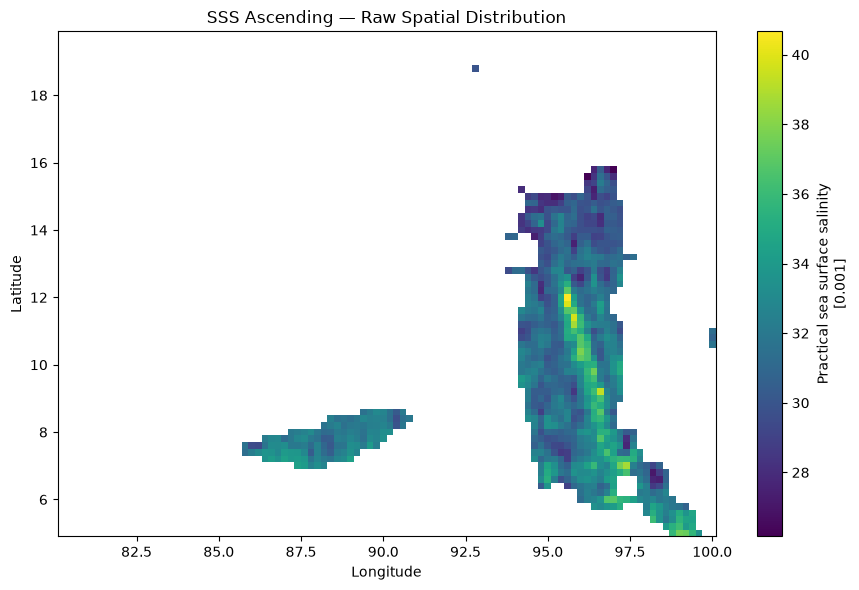

In [191]:
plt.figure(figsize=(9, 6))

sss_asc_da.isel(time=0).plot(
    cmap="viridis"
)

plt.title("SSS Ascending — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

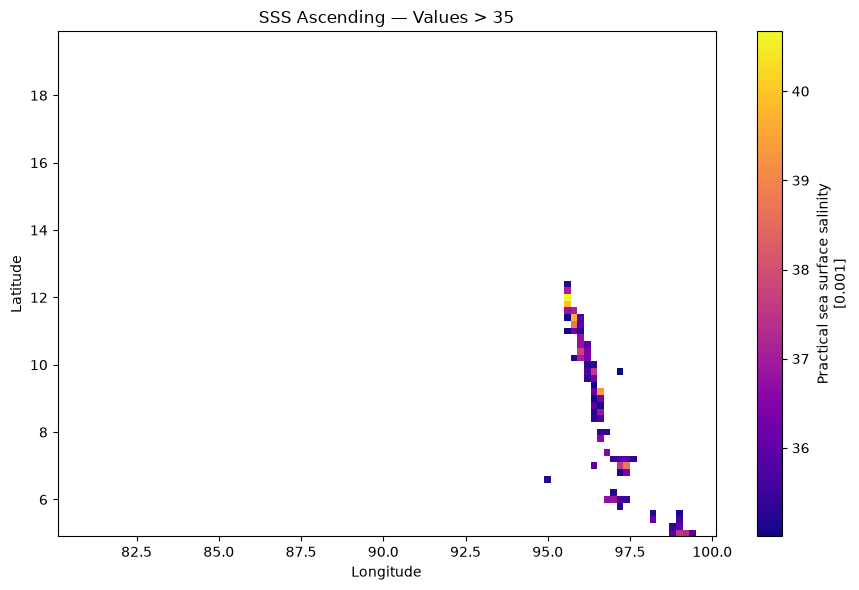

In [192]:
plt.figure(figsize=(9, 6))

sss_asc_extreme.isel(time=0).plot(
    cmap="plasma"
)

plt.title("SSS Ascending — Values > 35")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_extremes_gt35.png", #this plot is imp ,we need to know that these extreme values for isolated pixels or not 
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [193]:
asc = sss_asc_da.isel(time=0)
desc = sss_desc_da.isel(time=0)

overlap = asc.notnull() & desc.notnull()

print("Overlap observations:", overlap.sum().item())
print("Overlap percentage:", overlap.mean().item() * 100)

Overlap observations: 43
Overlap percentage: 0.5733333333333334


In [194]:
sss_difference = asc - desc

print("SSS Ascending - Descending difference")
print("---------------------------------------")

print(
    "Mean:",
    sss_difference.where(overlap).mean().item()
)

print(
    "Median:",
    sss_difference.where(overlap).median().item()
)

print(
    "Std:",
    sss_difference.where(overlap).std().item()
)

print(
    "Min:",
    sss_difference.where(overlap).min().item()
)

print(
    "Max:",
    sss_difference.where(overlap).max().item()
)

SSS Ascending - Descending difference
---------------------------------------
Mean: -0.02941579557955265
Median: 0.2183837890625
Std: 1.3403358459472656
Min: -3.3704566955566406
Max: 2.0812034606933594


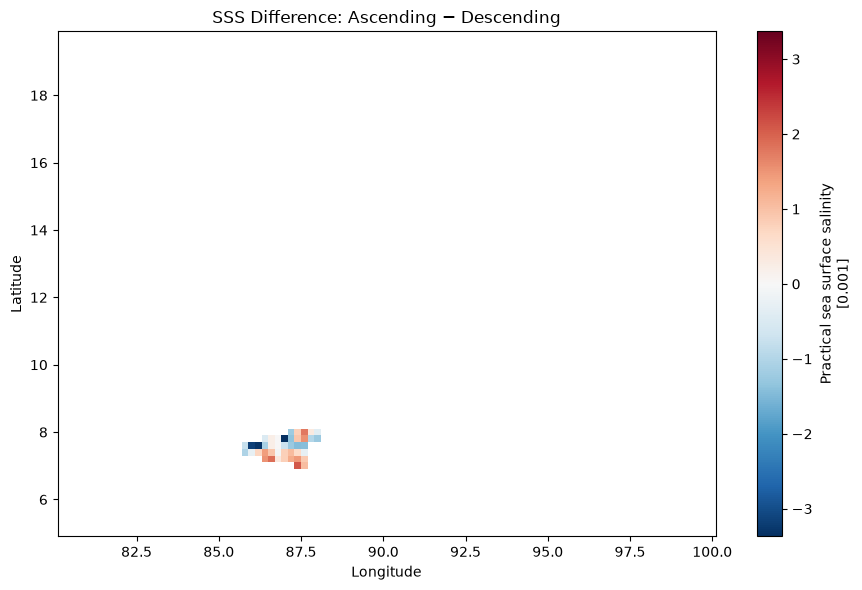

In [195]:
plt.figure(figsize=(9, 6))

sss_difference.where(overlap).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("SSS Difference: Ascending − Descending")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_ascending_minus_descending.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [196]:
high_asc = asc > 35

high_asc_overlap = high_asc & overlap

print(
    "Ascending SSS > 35 with descending observation:",
    high_asc_overlap.sum().item()
)

if high_asc_overlap.sum().item() > 0:
    print(
        "Mean difference at these locations:",
        sss_difference.where(high_asc_overlap).mean().item()
    )

    print(
        "Minimum difference:",
        sss_difference.where(high_asc_overlap).min().item()
    )

    print(
        "Maximum difference:",
        sss_difference.where(high_asc_overlap).max().item()
    )

Ascending SSS > 35 with descending observation: 0


### SSS Outlier Investigation — Initial Conclusion

The SSS ascending product contains a pronounced upper tail, with
7.87% of valid observations exceeding 35 and a maximum value of
approximately 40.67.

Spatial analysis shows that the high-salinity observations are
spatially structured rather than consisting solely of isolated
individual pixels. Therefore, these observations cannot be rejected
solely on the basis of their magnitude.

The ascending and descending products have very limited spatial
overlap in the current one-day prototype (~0.57%). None of the
ascending observations above 35 have a corresponding valid descending
observation. Consequently, ascending-descending comparison cannot
directly determine whether the high ascending values are erroneous.

The near-zero mean ascending-descending difference should also be
interpreted cautiously because it is calculated from only a small
overlap region.

Further investigation of the SSS quality-control and error variables
is required before defining a salinity outlier rule.

In [197]:
print("SSS Ascending variables:")
print(list(sss_asc.variables))

print("\nSSS Descending variables:")
print(list(sss_desc.variables))

SSS Ascending variables:
['Sea_Surface_Salinity', 'latitude', 'longitude', 'time']

SSS Descending variables:
['Sea_Surface_Salinity', 'latitude', 'longitude', 'time']


In [198]:
print("\nSSS Ascending data variables:")
print(list(sss_asc.data_vars))

print("\nSSS Descending data variables:")
print(list(sss_desc.data_vars))


SSS Ascending data variables:
['Sea_Surface_Salinity']

SSS Descending data variables:
['Sea_Surface_Salinity']


## 3. Spatial Exploratory Data Analysis

This section examines the spatial structure of the raw observations.

The objectives are to:

- visualize the spatial distribution of each surface variable
- identify spatially coherent features
- identify land/coastal effects
- inspect extreme-value locations
- understand the spatial pattern of missing observations
- assess whether missing values appear as isolated gaps or large unsupported regions

No interpolation, gap filling, regridding, or value modification is performed
during this stage.

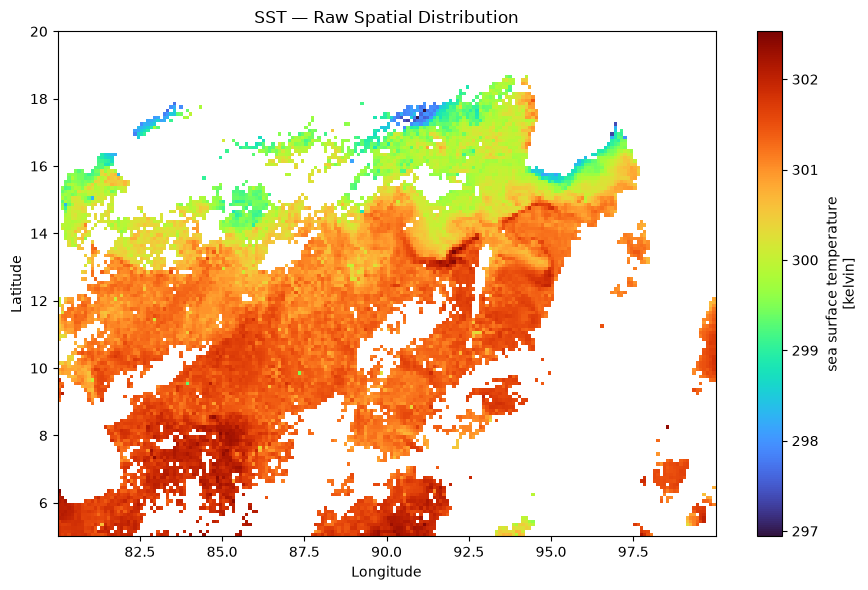

In [199]:
plt.figure(figsize=(9, 6))

sst["sea_surface_temperature"].isel(time=0).plot(
    cmap="turbo"
)

plt.title("SST — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The SST field has a very clear spatial gradient.

Broadly:

warmer temperatures dominate the southern part
cooler temperatures appear toward the north
there are localized structures and gradients
there are also gaps within the ocean coverage

The values are around 297–303 K, consistent with our earlier statistics.

Inference

The SST field is spatially coherent and physically structured.

That's good because SST is likely to be one of the strongest surface predictors for subsurface temperature.

Also notice something important:

The SST spatial structure looks broadly similar to the shallow GLORYS temperature structure.

That doesn't mean they're identical — and they shouldn't be — but the broad thermal patterns are consistent.

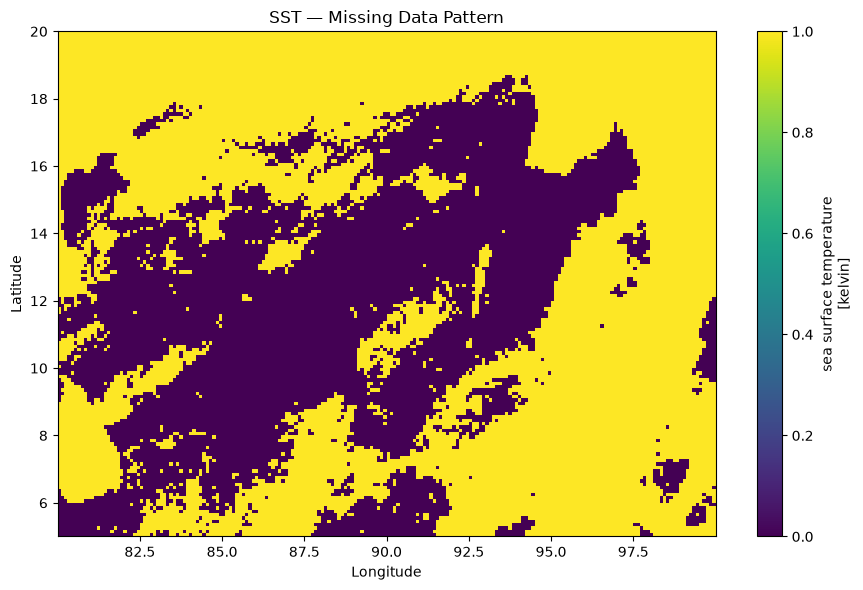

In [200]:
sst_missing = sst["sea_surface_temperature"].isel(time=0).isnull()

plt.figure(figsize=(9, 6))

sst_missing.plot()

plt.title("SST — Missing Data Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_missing_pattern.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The missing regions are not randomly scattered.

There are:

large coherent missing regions
irregular boundaries
smaller holes within observed regions
substantial areas of missing data

This explains our earlier:

58.06% missing

statistic.

Inference

The 58% number looks alarming by itself, but the map gives us the actual story:

SST missingness has strong spatial structure.

Therefore, we shouldn't say:

"SST has too many missing values, so the dataset is unusable."

Instead:

"SST has substantial but spatially structured missingness, requiring conservative gap treatment and an observation mask."

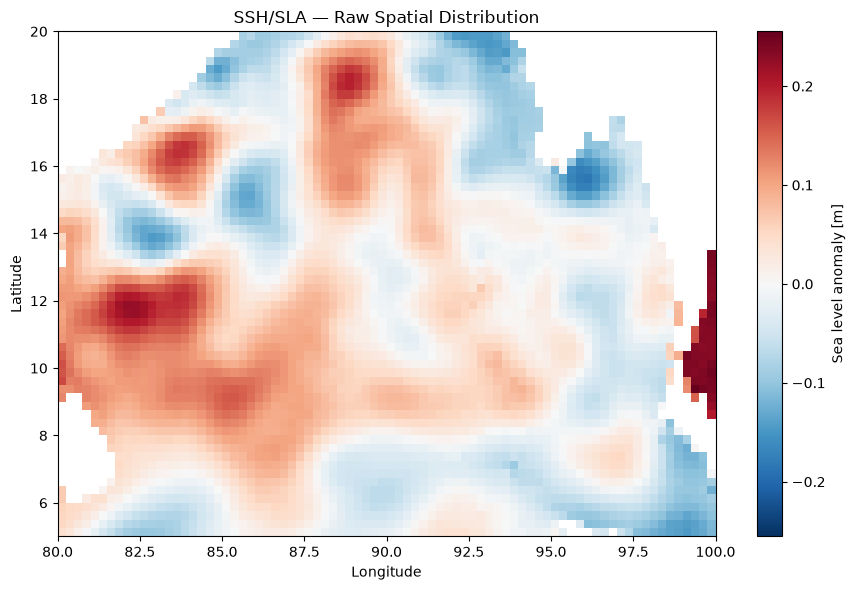

In [201]:
plt.figure(figsize=(9, 6))

ssh["sla"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("SSH/SLA — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "ssh_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

SSH/SLA — raw spatial distribution

This is a very good-looking oceanographic field.

What we see

* There are alternating positive and negative sea-level anomalies across the Bay of Bengal.

For example:

* positive anomalies around parts of the western/central domain
* negative anomalies toward other regions
* localized strong positive/negative features
* relatively smooth spatial transitions

Inference

* The SSH/SLA field contains mesoscale spatial structure rather than behaving like noise.

* These structures can be associated with ocean circulation features such as eddies and large-scale dynamical variability.

For our project, this is particularly important because SSH/SLA is one of the surface variables that potentially carries information about subsurface thermal structure.

Preprocessing implication

 * Preserve positive and negative values.

 * Keep the original sign.

 * Do not convert negative SLA to zero.

 * Do not use a generic positive-only normalization.

Our normalization later should be something like standardized scaling:

$$ x' = \frac{x-\mu}{\sigma} $$

using training data statistics.

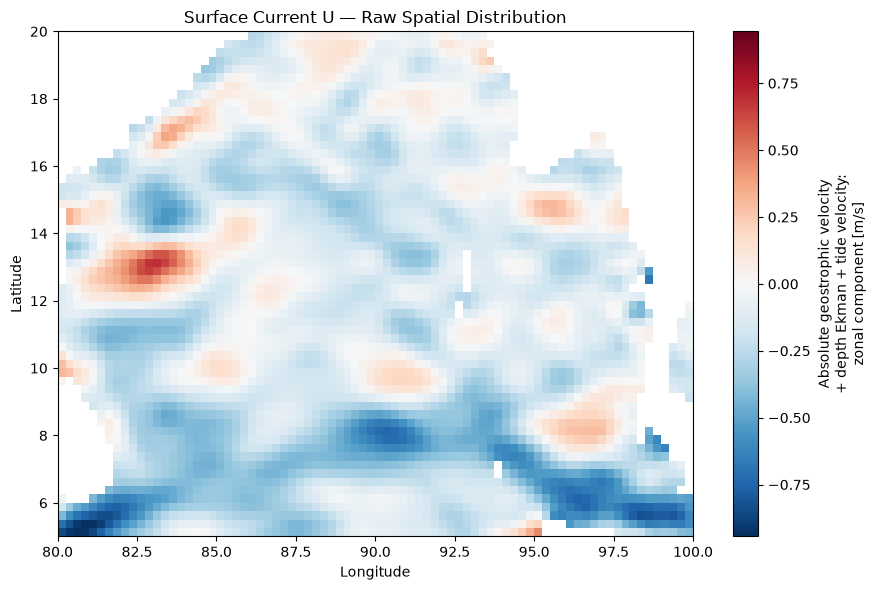

In [202]:
plt.figure(figsize=(9, 6))

currents["uo"].isel(time=0, depth=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Current U — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_u_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

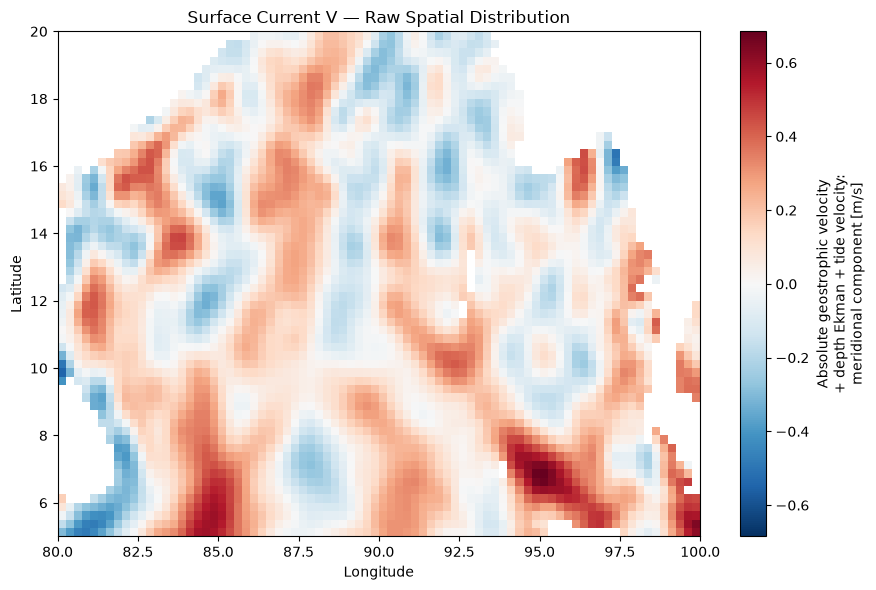

In [203]:
plt.figure(figsize=(9, 6))

currents["vo"].isel(time=0, depth=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Current V — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "current_v_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

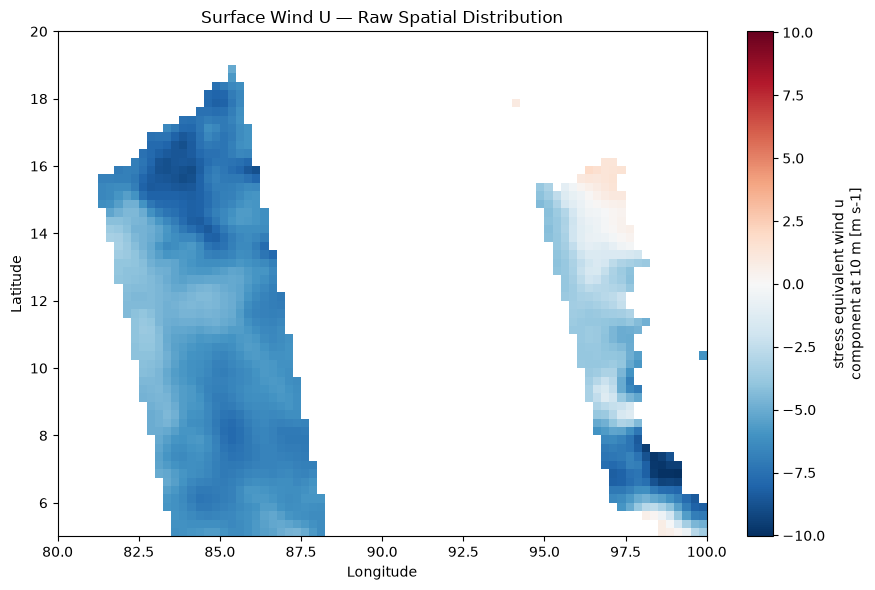

In [204]:
plt.figure(figsize=(9, 6))

winds["eastward_wind"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Wind U — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_u_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

Wind U isn't available over the entire domain.

Instead, there are two major observed spatial regions/footprints with substantial gaps between them.

The field itself is spatially structured within those footprints.

Inference

This is characteristic of the sampling/coverage pattern of the selected wind product, rather than evidence that wind velocity is zero outside the observed area.

This is crucial.

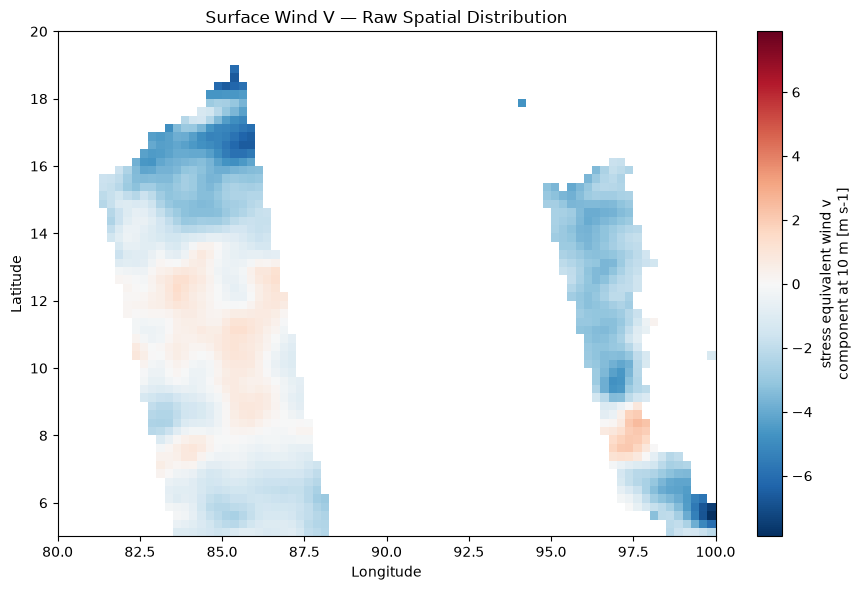

In [205]:
plt.figure(figsize=(9, 6))

winds["northward_wind"].isel(time=0).plot(
    cmap="RdBu_r",
    center=0
)

plt.title("Surface Wind V — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "wind_v_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

The V component shows a similar observation footprint but a different spatial pattern in the actual values.

What we see
Stronger negative values toward parts of the northern/western observed footprint.
More moderate values elsewhere.
Some positive regions exist.
The eastern/central missing regions correspond largely to lack of observations rather than zero wind.
Inference

The U and V components contain different information, which is exactly what we want.

Together:

$$ \vec{W}=(U,V) $$

describe the surface wind vector.

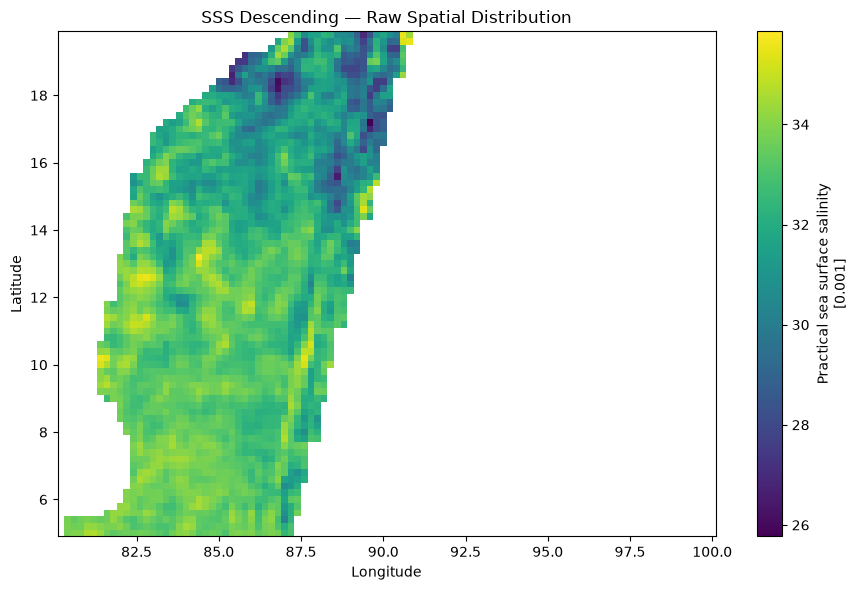

In [206]:
plt.figure(figsize=(9, 6))

sss_desc["Sea_Surface_Salinity"].isel(time=0).plot(
    cmap="viridis"
)

plt.title("SSS Descending — Raw Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_descending_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

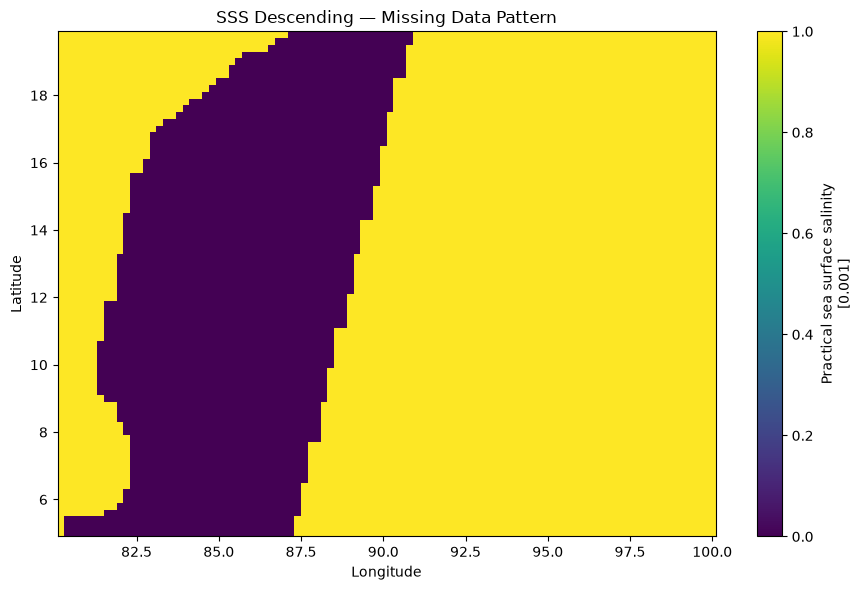

In [207]:
sss_desc_missing = (
    sss_desc["Sea_Surface_Salinity"]
    .isel(time=0)
    .isnull()
)

plt.figure(figsize=(9, 6))

sss_desc_missing.plot()

plt.title("SSS Descending — Missing Data Pattern")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sss_descending_missing_pattern.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see

The descending product has much broader coverage than the ascending product on this particular day, but it is still far from complete domain coverage.

There is a large contiguous observed region in the western/central portion of the domain, while much of the eastern side has no observations.

Inference

Again, missingness is structured, not random.

Also, ascending and descending clearly have different spatial sampling patterns.

This explains why their overlap was only about:

0.57%

for this particular sample.

This plot makes the previous point even clearer.

Remember:

yellow = missing
purple = observed

What we see

There is a very large contiguous missing region.

The observed region forms a broad spatial footprint rather than random scattered pixels.

Inference

This is observation-coverage missingness, not simply random sensor noise.

That means filling the entire yellow region using spatial interpolation would be dangerous.

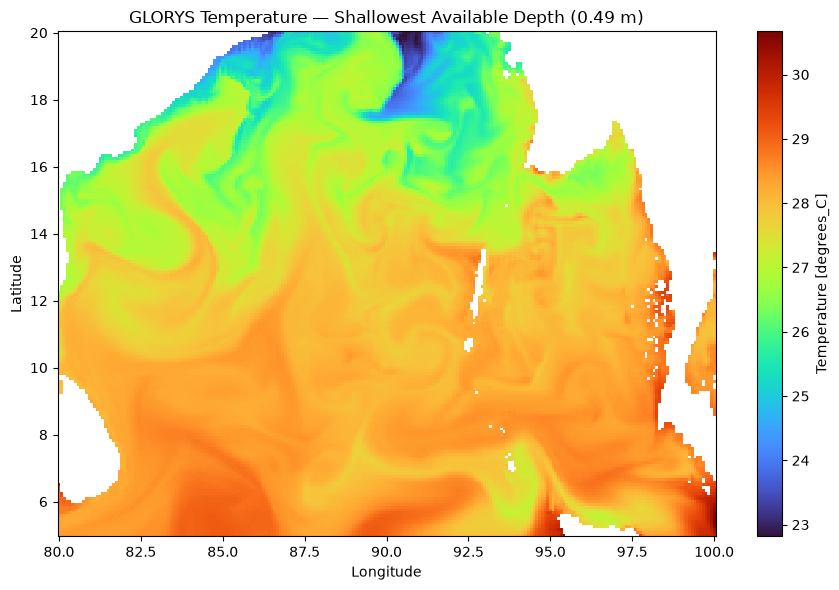

In [208]:
plt.figure(figsize=(9, 6))

glorys["thetao"].isel(time=0, depth=0).plot(
    cmap="turbo"
)

plt.title(
    f"GLORYS Temperature — Shallowest Available Depth "
    f"({glorys.depth.isel(depth=0).item():.2f} m)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_surface_spatial_raw.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

What we see
* Temperature is spatially structured, not random.
* The southern part of the domain is generally warmer, while the northern part is cooler.
* There are clear curved/mesoscale structures in the field.
* Temperatures are approximately 23–31°C in the plotted region.
* There are sharp gradients around some regions, especially toward the northern Bay of Bengal.
* There are also land/coastal/bathymetry-related missing regions.

Inference

This is exactly the kind of structure we expect from an ocean temperature field.

| Variable        | Main spatial observation                        | Preliminary preprocessing implication               |
| --------------- | ----------------------------------------------- | --------------------------------------------------- |
| **SST**         | Strong coherent thermal field + structured gaps | Convert K→°C; conservative interpolation + mask     |
| **SSS Asc**     | Very sparse, structured sampling                | Combine with descending; retain mask                |
| **SSS Desc**    | Broader but still incomplete coverage           | Combine with ascending; retain mask                 |
| **SSH/SLA**     | Strong positive/negative spatial structures     | Preserve sign and spatial variability               |
| **Current U/V** | Coherent velocity structures + missing regions  | Keep U/V separately; preserve masks                 |
| **Wind U/V**    | Strong sampling footprint + spatial variability | Keep U/V separately; never equate missing with zero |
| **GLORYS θ**    | Smooth/coherent thermal structures              | Preserve spatial structure; inspect depth-wise NaNs |


## 6. GLORYS Depth-wise Exploratory Data Analysis

The ANTARBODH target consists of subsurface temperature at 15 target
depths ranging from 0 m to 1000 m.

Before performing vertical interpolation, this section examines:

- temperature statistics as a function of depth
- the vertical temperature structure
- missing-data percentage at each native GLORYS depth
- the availability of data near the deepest target depth
- whether the selected 15 target depths are supported by the native GLORYS profile

No interpolation or modification of the GLORYS target is performed in
this section.

In [209]:
print("Number of native GLORYS depth levels:", glorys.sizes["depth"])

print("\nNative GLORYS depths:")
print(glorys["depth"].values)

Number of native GLORYS depth levels: 36

Native GLORYS depths:
[4.940250e-01 1.541375e+00 2.645669e+00 3.819495e+00 5.078224e+00
 6.440614e+00 7.929560e+00 9.572997e+00 1.140500e+01 1.346714e+01
 1.581007e+01 1.849556e+01 2.159882e+01 2.521141e+01 2.944473e+01
 3.443415e+01 4.034405e+01 4.737369e+01 5.576429e+01 6.580727e+01
 7.785385e+01 9.232607e+01 1.097293e+02 1.306660e+02 1.558507e+02
 1.861256e+02 2.224752e+02 2.660403e+02 3.181274e+02 3.802130e+02
 4.539377e+02 5.410889e+02 6.435668e+02 7.633331e+02 9.023393e+02
 1.062440e+03]


In [210]:
thetao = glorys["thetao"].isel(time=0)

depth_stats = []

for depth in glorys["depth"].values:

    field = thetao.sel(depth=depth)

    valid = field.where(np.isfinite(field))

    depth_stats.append({
        "depth": float(depth),
        "valid_count": int(valid.count().item()),
        "missing_count": int(valid.isnull().sum().item()),
        "missing_percent": float(
            valid.isnull().mean().item() * 100
        ),
        "min": float(valid.min().item()),
        "mean": float(valid.mean().item()),
        "max": float(valid.max().item()),
        "std": float(valid.std().item())
    })

depth_stats

[{'depth': 0.49402499198913574,
  'valid_count': 35400,
  'missing_count': 8221,
  'missing_percent': 18.84642717956947,
  'min': 22.8157292380929,
  'mean': 27.674091693111773,
  'max': 30.671926014125347,
  'std': 0.9653115684463714},
 {'depth': 1.5413750410079956,
  'valid_count': 35400,
  'missing_count': 8221,
  'missing_percent': 18.84642717956947,
  'min': 22.805475018918514,
  'mean': 27.668247802017603,
  'max': 30.646290466189384,
  'std': 0.9638602162499095},
 {'depth': 2.6456689834594727,
  'valid_count': 35400,
  'missing_count': 8221,
  'missing_percent': 18.84642717956947,
  'min': 22.798883020877838,
  'mean': 27.662297809963132,
  'max': 30.622852250933647,
  'std': 0.9621775517624442},
 {'depth': 3.8194949626922607,
  'valid_count': 35400,
  'missing_count': 8221,
  'missing_percent': 18.84642717956947,
  'min': 22.842829674482346,
  'mean': 27.659594035550196,
  'max': 30.64043091237545,
  'std': 0.9590351235524094},
 {'depth': 5.078224182128906,
  'valid_count': 354

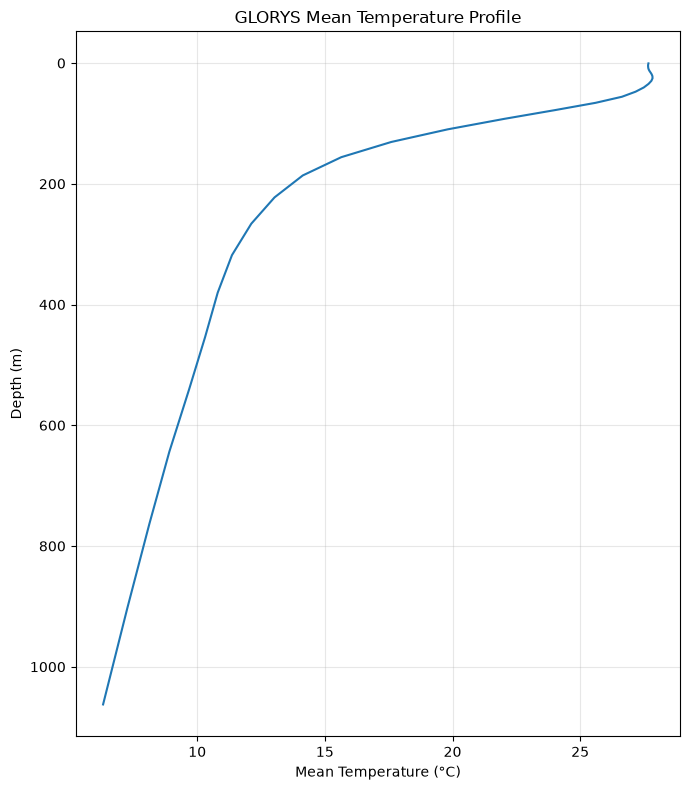

In [211]:
mean_profile = thetao.mean(dim=["latitude", "longitude"], skipna=True)

plt.figure(figsize=(7, 8))

plt.plot(
    mean_profile.values,
    glorys["depth"].values
)

plt.gca().invert_yaxis()

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("GLORYS Mean Temperature Profile")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_mean_temperature_profile.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

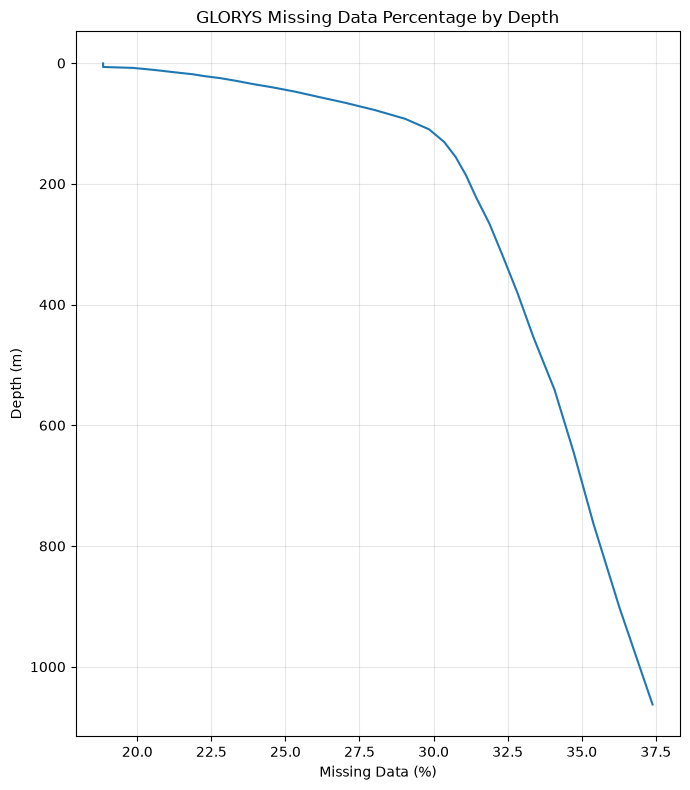

In [212]:
missing_by_depth = (
    thetao.isnull()
    .mean(dim=["latitude", "longitude"])
    * 100
)

plt.figure(figsize=(7, 8))

plt.plot(
    missing_by_depth.values,
    glorys["depth"].values
)

plt.gca().invert_yaxis()

plt.xlabel("Missing Data (%)")
plt.ylabel("Depth (m)")
plt.title("GLORYS Missing Data Percentage by Depth")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_missingness_by_depth.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [213]:
target_depths = np.array([
    0, 5, 10, 20, 30,
    50, 75, 100, 125, 150,
    200, 300, 500, 700, 1000
])

In [214]:
print("Target depth → nearest native GLORYS depth")
print("-" * 50)

for target_depth in target_depths:

    nearest_depth = float(
        glorys["depth"]
        .sel(depth=target_depth, method="nearest")
        .item()
    )

    difference = abs(nearest_depth - target_depth)

    print(
        f"{target_depth:>5.0f} m → "
        f"{nearest_depth:>8.3f} m "
        f"(difference: {difference:.3f} m)"
    )

Target depth → nearest native GLORYS depth
--------------------------------------------------
    0 m →    0.494 m (difference: 0.494 m)
    5 m →    5.078 m (difference: 0.078 m)
   10 m →    9.573 m (difference: 0.427 m)
   20 m →   18.496 m (difference: 1.504 m)
   30 m →   29.445 m (difference: 0.555 m)
   50 m →   47.374 m (difference: 2.626 m)
   75 m →   77.854 m (difference: 2.854 m)
  100 m →   92.326 m (difference: 7.674 m)
  125 m →  130.666 m (difference: 5.666 m)
  150 m →  155.851 m (difference: 5.851 m)
  200 m →  186.126 m (difference: 13.874 m)
  300 m →  318.127 m (difference: 18.127 m)
  500 m →  541.089 m (difference: 41.089 m)
  700 m →  643.567 m (difference: 56.433 m)
 1000 m → 1062.440 m (difference: 62.440 m)


In [215]:
deepest = thetao.sel(
    depth=1000,
    method="nearest"
)

print(
    "Nearest native depth to 1000 m:",
    float(
        glorys["depth"]
        .sel(depth=1000, method="nearest")
        .item()
    )
)

print(
    "Valid fraction:",
    float(deepest.notnull().mean().item() * 100),
    "%"
)

Nearest native depth to 1000 m: 1062.43994140625
Valid fraction: 62.6097521835813 %


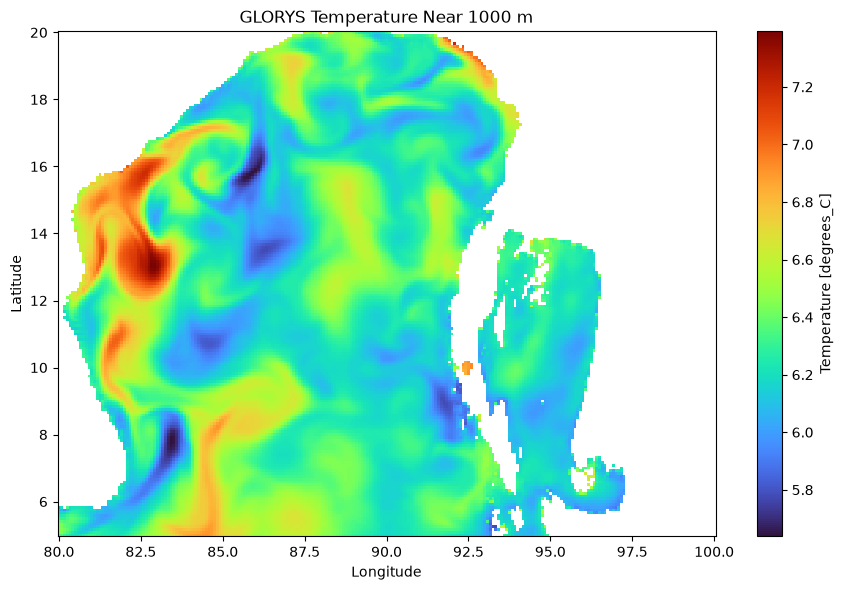

In [216]:
plt.figure(figsize=(9, 6))

deepest.plot(
    cmap="turbo"
)

plt.title(
    "GLORYS Temperature Near 1000 m"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "glorys_1000m_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### GLORYS Depth-wise EDA — Findings

The GLORYS temperature field exhibits a strong and physically meaningful
vertical structure.

Mean temperature decreases from approximately 27.7 °C near the surface
to approximately 6.3 °C at the deepest available level (~1062 m), with
the strongest temperature variation occurring in the upper ocean.

Missing-data percentage increases gradually with depth, from approximately
18.8% near the surface to approximately 37.4% at the deepest level.
Therefore, deeper levels remain sufficiently represented for the prototype
and should not be discarded solely because of increased missingness.

The deepest ANTARBODH target depth of 1000 m lies within the native GLORYS
depth range, between approximately 902 m and 1062 m, so it can be obtained
through vertical interpolation.

The 0 m target requires special handling because the shallowest native
GLORYS level is approximately 0.49 m. Blind extrapolation to 0 m should
be avoided.

No vertical interpolation or missing-value filling is performed during
this EDA stage. These operations will be addressed during preprocessing.

# 7. Cross-Variable Relationship EDA

The objective of this section is to examine the statistical relationships
between the surface observations used as ANTARBODH inputs and the GLORYS
subsurface temperature field used as the reconstruction target.

The surface variables considered are:

- Sea Surface Temperature (SST)
- Sea Surface Salinity (SSS)
- Sea Surface Height Anomaly (SSH/SLA)
- Surface Current U component
- Surface Current V component
- Surface Wind U component
- Surface Wind V component

The primary target variable is GLORYS potential temperature (thetao)
at different depths.

This analysis helps determine whether surface observations contain
statistical information related to subsurface thermal structure.

The analysis includes:

1. SST versus GLORYS temperature relationships
2. SST correlation with temperature at multiple depths
3. Surface-variable correlations with subsurface temperature
4. Correlation as a function of depth
5. Interpretation of the relationships and their limitations

No interpolation, missing-value filling, normalization, or other
permanent preprocessing is performed in this section. Temporary
interpolation/alignment may be used only to compare variables that are
defined on different native grids.

## 7.1 Why Cross-Variable Relationship Analysis?

ANTARBODH is based on the hypothesis that surface ocean observations
contain information about the subsurface thermal structure.

Before training a machine-learning model, it is useful to investigate
whether measurable statistical relationships exist between the surface
inputs and subsurface temperature.

For example:

Surface SST
     ↓
may contain information about
     ↓
temperature at 50 m, 100 m, 200 m, etc.

However, SST alone is not expected to completely describe the subsurface
ocean.

Other variables such as salinity, sea-level anomaly, currents, and winds
may provide additional information.

Therefore, this section evaluates both individual relationships and
the combined set of surface observables.

Correlation is used as an exploratory measure, not as proof of causality.
A low correlation between an individual surface variable and a deep
temperature field does not imply that the variable is useless for a
nonlinear machine-learning model.

In [217]:
# Convert SST from Kelvin to Celsius for comparison with GLORYS

sst_c = sst - 273.15

sst_c.attrs = sst.attrs.copy()
sst_c.attrs["units"] = "degrees_Celsius"

print("SST units:", sst_c.attrs["units"])
print(
    "SST range:",
    float(sst_c["sea_surface_temperature"].min().item()),
    "to",
    float(sst_c["sea_surface_temperature"].max().item()),
    "°C"
)

SST units: degrees_Celsius
SST range: 22.029999999999973 to 30.920000000000016 °C


In [218]:
# Extract SST variable and convert Kelvin → Celsius
sst_c = sst["sea_surface_temperature"] - 273.15

sst_c.attrs = sst["sea_surface_temperature"].attrs.copy()
sst_c.attrs["units"] = "degrees_Celsius"

print("Type:", type(sst_c))
print("Dimensions:", sst_c.dims)
print("Units:", sst_c.attrs["units"])
print(
    "SST range:",
    float(sst_c.min().item()),
    "to",
    float(sst_c.max().item()),
    "°C"
)

Type: <class 'xarray.core.dataarray.DataArray'>
Dimensions: ('time', 'latitude', 'longitude')
Units: degrees_Celsius
SST range: 22.029999999999973 to 30.920000000000016 °C


In [219]:
glorys_surface = glorys["thetao"].isel(
    time=0,
    depth=0
)

print("GLORYS type:", type(glorys_surface))
print(
    "GLORYS depth:",
    float(glorys["depth"].isel(depth=0).item()),
    "m"
)

GLORYS type: <class 'xarray.core.dataarray.DataArray'>
GLORYS depth: 0.49402499198913574 m


In [220]:
glorys_surface_on_sst = glorys_surface.interp(
    latitude=sst_surface.latitude,
    longitude=sst_surface.longitude
)

print("Interpolated GLORYS type:", type(glorys_surface_on_sst))
print("Shape:", glorys_surface_on_sst.shape)

Interpolated GLORYS type: <class 'xarray.core.dataarray.DataArray'>
Shape: (150, 200)


In [221]:
valid_surface = (
    sst_surface.notnull()
    & glorys_surface_on_sst.notnull()
)

print("Mask type:", type(valid_surface))
print("Mask shape:", valid_surface.shape)

Mask type: <class 'xarray.core.dataarray.DataArray'>
Mask shape: (150, 200)


In [222]:
print(
    "Valid SST–GLORYS surface comparison points:",
    int(valid_surface.sum().item())
)

print(
    "Valid comparison percentage:",
    float(valid_surface.mean().item() * 100),
    "%"
)

Valid SST–GLORYS surface comparison points: 12474
Valid comparison percentage: 41.58 %


In [223]:
sst_surface = sst_c.isel(time=0)

surface_corr = xr.corr(
    sst_surface.where(valid_surface),
    glorys_surface_on_sst.where(valid_surface)
)

print(
    "SST vs GLORYS surface temperature correlation:",
    float(surface_corr.item())
)

SST vs GLORYS surface temperature correlation: 0.8573201735841558


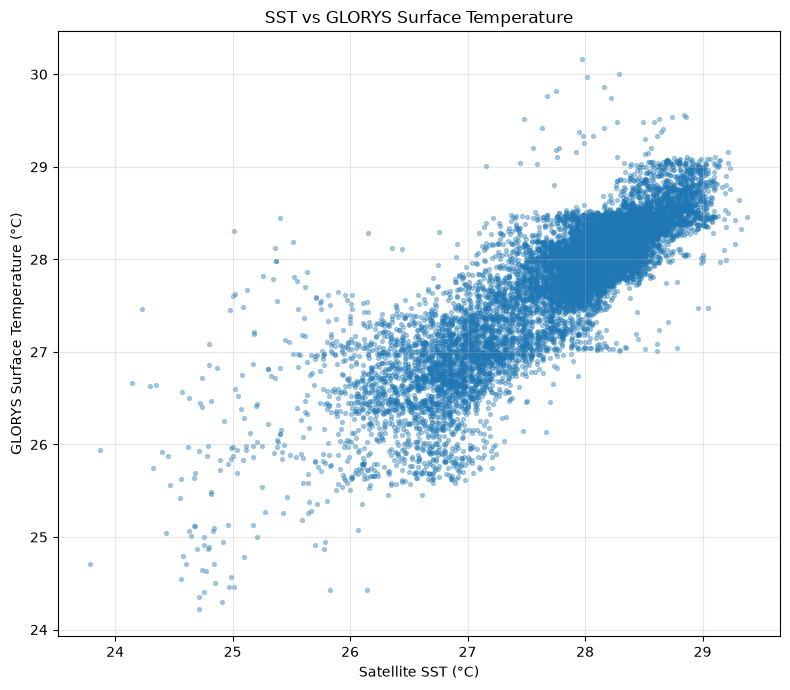

In [224]:
sst_values = sst_surface.where(valid_surface).values.flatten()
glorys_values = glorys_surface_on_sst.where(valid_surface).values.flatten()

valid = (
    np.isfinite(sst_values)
    & np.isfinite(glorys_values)
)

sst_values = sst_values[valid]
glorys_values = glorys_values[valid]

plt.figure(figsize=(8, 7))

plt.scatter(
    sst_values,
    glorys_values,
    s=8,
    alpha=0.35
)

plt.xlabel("Satellite SST (°C)")
plt.ylabel("GLORYS Surface Temperature (°C)")
plt.title("SST vs GLORYS Surface Temperature")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_vs_glorys_surface_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 7.8 SST–Subsurface Temperature Relationship

The relationship between SST and GLORYS temperature is evaluated at
multiple depths.

The selected depths provide a broad representation of:

- near-surface water
- upper-ocean structure
- thermocline-region variability
- intermediate/deeper ocean
- deep ocean

Correlation is calculated only over spatial locations where both SST
and GLORYS temperature are valid.

In [225]:
test_depths = [
    5,
    50,
    100,
    200,
    500,
    700,
    1000
]

sst_depth_correlations = []

for target_depth in test_depths:

    # Temporarily interpolate GLORYS vertically
    theta_depth = glorys["thetao"].isel(time=0).interp(
        depth=target_depth
    )

    # Temporarily align GLORYS horizontally to SST grid
    theta_on_sst = theta_depth.interp(
        latitude=sst_surface.latitude,
        longitude=sst_surface.longitude
    )

    # Valid comparison mask
    valid = (
        sst_surface.notnull()
        & theta_on_sst.notnull()
    )

    corr = xr.corr(
        sst_surface.where(valid),
        theta_on_sst.where(valid)
    )

    sst_depth_correlations.append(
        float(corr.item())
    )

    print(
        f"{target_depth:>4} m : "
        f"correlation = {float(corr.item()):.4f}"
    )

   5 m : correlation = 0.8460
  50 m : correlation = 0.0083
 100 m : correlation = -0.0720
 200 m : correlation = 0.0940
 500 m : correlation = 0.1891
 700 m : correlation = 0.0537
1000 m : correlation = 0.0478


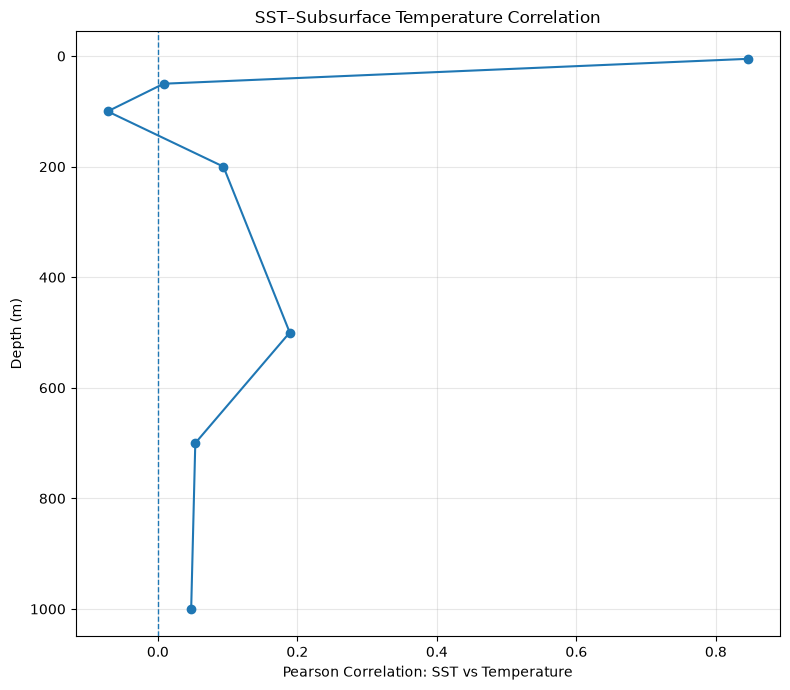

In [226]:
plt.figure(figsize=(8, 7))

plt.plot(
    sst_depth_correlations,
    test_depths,
    marker="o"
)

plt.gca().invert_yaxis()

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Pearson Correlation: SST vs Temperature")
plt.ylabel("Depth (m)")
plt.title("SST–Subsurface Temperature Correlation")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "sst_subsurface_temperature_correlation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [227]:
sst_corr_profile = xr.DataArray(
    sst_depth_correlations,
    coords={
        "depth": test_depths
    },
    dims=["depth"],
    name="sst_temperature_correlation"
)

sst_corr_profile.attrs = {
    "description": "Pearson correlation between SST and GLORYS temperature",
    "units": "correlation coefficient",
    "source": "Raw prototype data",
    "note": "Temporary spatial/vertical interpolation used for EDA only"
}

print(sst_corr_profile)




<xarray.DataArray 'sst_temperature_correlation' (depth: 7)> Size: 56B
array([ 0.84604088,  0.00830872, -0.07201167,  0.09401804,  0.1890606 ,
        0.05365678,  0.047761  ])
Coordinates:
  * depth    (depth) int64 56B 5 50 100 200 500 700 1000
Attributes:
    description:  Pearson correlation between SST and GLORYS temperature
    units:        correlation coefficient
    source:       Raw prototype data
    note:         Temporary spatial/vertical interpolation used for EDA only


In [228]:
sst_corr_profile.to_netcdf(
    OUTPUT_DIR / "sst_subsurface_temperature_correlation.nc"
)

## Step 7 Inference:
 The one-day analysis shows a strong positive relationship between satellite SST and GLORYS near-surface temperature (r = 0.857). However, the correlation decreases sharply with depth, reaching approximately zero by 50 m for SST alone. This indicates that SST alone does not contain a sufficiently strong linear signal for reconstructing the deeper temperature profile. The result motivates AntarBodh's multivariate approach, in which SST, SSS, SSH/SLA, surface currents, and winds are jointly used to learn the nonlinear relationship between surface observations and subsurface temperature. These findings are preliminary because they are based on a single day and must be reassessed over the full temporal dataset.

In [229]:
surface_variables = {
    "SST": sst_c.isel(time=0),
    "SSH": ssh["sla"].isel(time=0),
    "Current_U": currents["uo"].isel(time=0).squeeze(),
    "Current_V": currents["vo"].isel(time=0).squeeze(),
    "Wind_U": winds["eastward_wind"].isel(time=0),
    "Wind_V": winds["northward_wind"].isel(time=0),
}

In [230]:
sss_asc = sss_asc["Sea_Surface_Salinity"].isel(time=0) 
sss_desc = sss_desc["Sea_Surface_Salinity"].isel(time=0)


# Combine SSS Ascending and Descending into a single variable temporarily for EDA purposes


sss_combined = xr.where(
    sss_asc.notnull() & sss_desc.notnull(),
    (sss_asc + sss_desc) / 2,
    xr.where(
        sss_asc.notnull(),
        sss_asc,
        sss_desc
    )
)
#Both Valid-Average, if only one valid, take that value, if both invalid, result is NaN
surface_variables["SSS"] = sss_combined

In [231]:
for name, variable in surface_variables.items():

    print(
        f"{name:12s} | "
        f"shape={variable.shape} | "
        f"min={float(variable.min().item()):.3f} | "
        f"max={float(variable.max().item()):.3f}"
    )

SST          | shape=(150, 200) | min=23.790 | max=29.380
SSH          | shape=(60, 80) | min=-0.184 | max=0.255
Current_U    | shape=(60, 80) | min=-0.944 | max=0.700
Current_V    | shape=(60, 80) | min=-0.551 | max=0.685
Wind_U       | shape=(60, 80) | min=-10.040 | max=1.950
Wind_V       | shape=(60, 80) | min=-7.900 | max=2.480
SSS          | shape=(75, 100) | min=25.770 | max=40.671


In [232]:
relationship_depths = [
    5,
    50,
    100,
    200,
    500,
    700,
    1000
]

In [233]:
correlation_results = {}

for variable_name, surface_variable in surface_variables.items():

    print("\n", variable_name)
    print("-" * 50)

    correlations = []

    # Put surface variable onto GLORYS horizontal grid
    surface_on_glorys = surface_variable.interp(
        latitude=glorys.latitude,
        longitude=glorys.longitude
    )

    for target_depth in relationship_depths:

        theta_depth = glorys["thetao"].isel(time=0).interp(
            depth=target_depth
        )

        valid = (
            surface_on_glorys.notnull()
            & theta_depth.notnull()
        )

        corr = xr.corr(
            surface_on_glorys.where(valid),
            theta_depth.where(valid)
        )

        corr_value = float(corr.item())

        correlations.append(corr_value)

        print(
            f"{target_depth:>4} m : "
            f"{corr_value:.4f}"
        )

    correlation_results[variable_name] = correlations


 SST
--------------------------------------------------
   5 m : 0.8571
  50 m : 0.0236
 100 m : -0.0143
 200 m : 0.1558
 500 m : 0.1944
 700 m : 0.0489
1000 m : 0.0307

 SSH
--------------------------------------------------
   5 m : 0.1943
  50 m : 0.5000
 100 m : 0.7208
 200 m : 0.5869
 500 m : 0.0409
 700 m : -0.0652
1000 m : 0.1123

 Current_U
--------------------------------------------------
   5 m : -0.2965
  50 m : 0.1499
 100 m : 0.1779
 200 m : 0.0566
 500 m : -0.1096
 700 m : 0.0200
1000 m : 0.1318

 Current_V
--------------------------------------------------
   5 m : 0.3375
  50 m : -0.1059
 100 m : 0.0279
 200 m : 0.0880
 500 m : 0.2508
 700 m : 0.1870
1000 m : 0.0909

 Wind_U
--------------------------------------------------
   5 m : -0.0867
  50 m : -0.3675
 100 m : -0.3570
 200 m : 0.0451
 500 m : 0.1025
 700 m : 0.0904
1000 m : 0.0328

 Wind_V
--------------------------------------------------
   5 m : 0.3363
  50 m : 0.3618
 100 m : 0.3223
 200 m : 0.0215
 500 m :

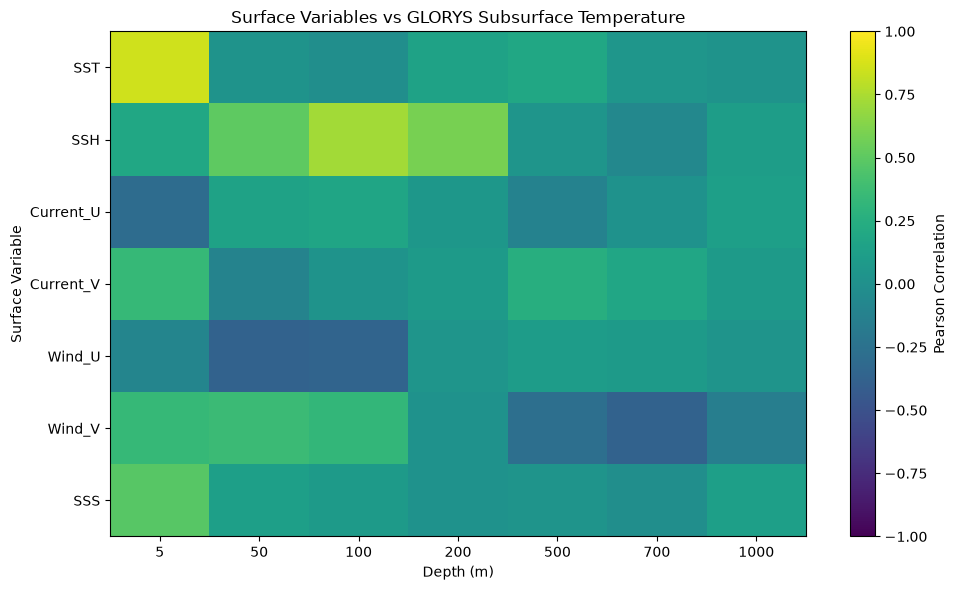

In [234]:
correlation_array = np.array(
    list(correlation_results.values())
)

plt.figure(figsize=(10, 6))

plt.imshow(
    correlation_array,
    aspect="auto",
    interpolation="nearest",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Pearson Correlation"
)

plt.xticks(
    range(len(relationship_depths)),
    relationship_depths
)

plt.yticks(
    range(len(correlation_results)),
    list(correlation_results.keys())
)

plt.xlabel("Depth (m)")
plt.ylabel("Surface Variable")

plt.title(
    "Surface Variables vs GLORYS Subsurface Temperature"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "surface_variables_vs_subsurface_temperature.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [235]:
correlation_matrix = xr.DataArray(
    correlation_array,
    coords={
        "surface_variable": list(correlation_results.keys()),
        "depth": relationship_depths
    },
    dims=[
        "surface_variable",
        "depth"
    ],
    name="surface_subsurface_temperature_correlation"
)

correlation_matrix.attrs = {
    "description": (
        "Pearson correlation between surface observations "
        "and GLORYS temperature at selected depths"
    ),
    "note": (
        "Temporary spatial and vertical interpolation used "
        "for exploratory analysis only"
    )
}

print(correlation_matrix)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 392B
array([[ 0.85706205,  0.02360586, -0.0142923 ,  0.15575432,  0.19435592,
         0.0488757 ,  0.03065074],
       [ 0.19432622,  0.50002025,  0.72083562,  0.5869228 ,  0.04086317,
        -0.06517692,  0.1122935 ],
       [-0.29645244,  0.1499181 ,  0.1778744 ,  0.05664362, -0.10962333,
         0.02000934,  0.13184669],
       [ 0.33747454, -0.10590624,  0.02793559,  0.08802997,  0.25082966,
         0.18702574,  0.0908596 ],
       [-0.08671057, -0.36753288, -0.35700259,  0.04513062,  0.1024662 ,
         0.09037232,  0.03280046],
       [ 0.3362911 ,  0.36183474,  0.32229323,  0.02154482, -0.27038986,
        -0.37279766, -0.14761972],
       [ 0.47868218,  0.12897263,  0.08809069,  0.0169836 ,  0.03573744,
        -0.01518681,  0.13020798]])
Coordin

In [236]:
correlation_matrix.to_netcdf(
    OUTPUT_DIR / "surface_subsurface_temperature_correlations.nc"
)

In [237]:
absolute_correlation = abs(correlation_matrix)

print(absolute_correlation)

<xarray.DataArray 'surface_subsurface_temperature_correlation' (
                                                                surface_variable: 7,
                                                                depth: 7)> Size: 392B
array([[0.85706205, 0.02360586, 0.0142923 , 0.15575432, 0.19435592,
        0.0488757 , 0.03065074],
       [0.19432622, 0.50002025, 0.72083562, 0.5869228 , 0.04086317,
        0.06517692, 0.1122935 ],
       [0.29645244, 0.1499181 , 0.1778744 , 0.05664362, 0.10962333,
        0.02000934, 0.13184669],
       [0.33747454, 0.10590624, 0.02793559, 0.08802997, 0.25082966,
        0.18702574, 0.0908596 ],
       [0.08671057, 0.36753288, 0.35700259, 0.04513062, 0.1024662 ,
        0.09037232, 0.03280046],
       [0.3362911 , 0.36183474, 0.32229323, 0.02154482, 0.27038986,
        0.37279766, 0.14761972],
       [0.47868218, 0.12897263, 0.08809069, 0.0169836 , 0.03573744,
        0.01518681, 0.13020798]])
Coordinates:
  * surface_variable  (surface_variable) <U

## 7.19 Cross-Variable EDA Interpretation

The cross-variable analysis will be interpreted using the following
principles:

### SST

SST is expected to have the strongest relationship with temperature
near the surface. Its relationship may weaken with increasing depth.

If SST retains meaningful correlation at subsurface depths, this provides
evidence that surface thermal conditions contain information about the
subsurface thermal structure.

### SSS

SSS may provide complementary information because salinity contributes
to seawater density and ocean stratification.

However, the SSS observations are substantially sparser than SST, so
correlation values must be interpreted together with observation
coverage.

### SSH/SLA

SSH/SLA may contain information associated with large-scale ocean
dynamics, eddies, and subsurface structure.

Its relationship with temperature may therefore remain meaningful at
depths where SST alone becomes less informative.

### Surface Currents

Current U and V components represent horizontal ocean dynamics.

Their individual linear correlation with temperature may be modest,
but they may still provide useful nonlinear information to a machine
learning model.

### Surface Winds

Surface winds represent atmospheric forcing and can influence mixing
and upper-ocean structure.

Their direct linear correlation with temperature at depth may be weak,
but they may provide complementary predictive information.

### Important limitation

Correlation measures only linear statistical association.

A low Pearson correlation does not mean that a variable contains no
useful information for ANTARBODH. A neural network can learn nonlinear
and multivariate relationships that are not captured by pairwise
correlation.

Therefore, this analysis is used for EDA and feature understanding,
not for automatically removing variables.

### Feature Selection Policy

The correlation analysis will not be used to automatically remove
surface variables.

All seven planned input channels will initially be retained:

SST, SSS, SSH, Current U, Current V, Wind U, Wind V.

Feature removal will only be considered later if there is a strong
data-quality, redundancy, or experimental reason.

The purpose of this EDA is to understand the data and guide modelling
experiments rather than to prematurely simplify the input feature set.

## Step 7 — Multi-Variable Relationship Analysis: Inference

The one-day prototype was used to investigate the spatial Pearson correlation
between seven surface observations and GLORYS subsurface temperature at selected
depths.

The results show that no single surface variable exhibits a strong relationship
with subsurface temperature across the full depth range.

SST shows the strongest relationship at 5 m (r = 0.857), but its correlation
decreases rapidly with depth. In contrast, SSH exhibits substantially stronger
relationships in the upper subsurface, reaching r = 0.721 at 100 m and r = 0.587
at 200 m. SSS shows a moderate near-surface relationship (r = 0.479 at 5 m),
while surface current and wind components exhibit weaker but depth-dependent
relationships.

These results provide preliminary evidence that different surface observations
contain complementary information about different portions of the subsurface
thermal structure.

This supports the use of a multivariate input representation containing SST,
SSS, SSH, surface currents, and surface winds rather than relying on SST alone.

However, these Pearson correlations represent only linear spatial associations
for a single day and should not be interpreted as causal relationships or as
direct measures of model predictive performance. Weak individual correlations
also do not imply that a variable contains no predictive information, because
the final model may learn nonlinear interactions between multiple surface
variables.

The results will therefore be treated as exploratory evidence supporting the
multivariate AntarBodh architecture. The actual reconstruction capability will
be evaluated later using held-out GLORYS data and independent ARGO/INCOIS
observations.

# STEP 8 — Quality-Control Decisions

Before transforming the raw oceanographic datasets, we define quality-control
(QC) rules for each surface observation and the GLORYS target.

The purpose of QC is to distinguish between:

1. valid observations that should be retained,
2. physically implausible or invalid observations that should be masked,
3. missing observations that may be conservatively estimated, and
4. large unsupported gaps that should remain missing.

QC decisions are based on the statistical and spatial exploratory analysis
performed earlier in this notebook.

The QC process is intentionally conservative. Observations are not removed
solely because they are statistically extreme. Spatial structure, physical
meaning, missing-data patterns, dataset metadata, and variable-specific
characteristics are considered before defining a QC rule.

The same QC philosophy will later be applied consistently when the prototype
is scaled from one day to the full 2020–2025 period.

The output of this section is a documented set of QC rules that will be
implemented in the subsequent preprocessing steps.

```mermaid
flowchart TD
    A[RAW OBSERVATION] --> B{Is it missing?}
    B -->|YES| C[Leave missing for later treatment]
    B -->|NO| D{Is it valid?}
    D -->|YES| E[KEEP]
    D -->|NO| F[MASK]

```

Principle 1 — Don't delete observations just because they're extreme
Principle 2 — Use metadata-defined invalid/fill values first
Principle 3 — Physical plausibility checks come after metadata checks

### SST

Your prototype showed:


```bash
Missing: ~58%
Raw units: Kelvin
Range: ~296.94–302.53 K
```


Converted:

~23.79–29.38 °C

Those temperatures are plausible for the Bay of Bengal prototype.

* Decision

Keep all valid SST observations.

* Do:

Kelvin
  ↓
Celsius

* and mask only:

* explicit fill values
* NaN
* clearly invalid metadata-defined values

Do not remove the high end simply because it is high.

Missingness

SST has substantial missingness.

We should not globally fill it.

Later we can perform conservative spatial interpolation where appropriate and preserve a mask.

### SSS

This is our most delicate variable.

You found:

Ascending
```bash
valid: ~11.9%
missing: ~88.1%
range: 26.16–40.67
Descending
valid: ~32.6%
missing: ~67.4%
range: 25.77–35.86

```

And importantly:

* ascending and descending overlap was extremely small
* high ascending values did not have corresponding descending observations
* high ascending values showed coherent swath-like structure

Therefore we cannot justify simply deleting SSS >35 based on this prototype.

Decision

First:

SSS ascending
      +
SSS descending
      ↓
combined SSS

using:

both valid
    → mean

ascending only
    → ascending

descending only
    → descending

neither
    → NaN

But importantly, this combination should happen after basic invalid/fill-value handling.

Missingness

SSS is extremely sparse.

Therefore:

We must not aggressively spatially interpolate SSS across large gaps.

### SSH / SLA

Your SSH:


```bash
missing: ~15.9%
range: -0.184 to +0.255 m
```

This looks like a reasonable SLA-type field.

Decision

Keep valid observations.

Mask:

NaN
explicit fill/invalid values

Do not remove positive or negative values simply because they're relatively large.

The positive and negative values are part of the spatial SSH anomaly field.

Later:

conservative spatial interpolation may be applied to small gaps.

Large gaps remain masked.

### Surface currents

You have:

U
```bash
range ≈ -0.944 to +0.700 m/s
V
range ≈ -0.551 to +0.685 m/s
```

These are components of velocity.

This is important:

Current_U < 0

does not mean invalid.

It means the flow has a westward component.

Likewise:

Current_V < 0

means a southward component.

Decision

Do not filter negative currents.

Keep valid U/V values.

Mask only:

explicit fill values
NaN
clearly invalid metadata-defined values

We will preserve U and V as separate channels.

### Winds

Your wind fields showed:

missing: ~72.4%

with:

Wind_U: approximately -10 to +2 m/s
Wind_V: approximately -8 to +2.5 m/s

The high missingness is consistent with the swath-like observational coverage we saw.

Very important:

Do not interpret:

Wind_U = -8 m/s

as an invalid value.

It represents wind direction.

Decision

Keep valid wind observations.

Mask:

explicit invalid/fill values
NaN

Do not fill the entire domain with zero.

And because the swath coverage is sparse:

Large gaps should remain masked rather than being aggressively interpolated.

### GLORYS target

GLORYS is different.

It's not a surface observation we're trying to clean for input.

It is our training/reference target.

We need to be particularly careful not to manufacture target values.

You found:

missingness increases with depth

approximately:

surface       ~19%
100 m         ~29–30%
500 m         ~34%
1000 m        ~37%

This is important.

Decision

Do not globally fill missing GLORYS temperature.

Instead:

valid GLORYS
     ↓
retain

invalid/missing GLORYS
     ↓
mask

Later, when constructing training samples, the target mask determines whether a location/depth can contribute to the loss.

| Variable | QC decision | Missing-data treatment |
|----------|-------------|------------------------|
| SST | Remove explicit invalid/fill values; convert K → °C | Preserve mask; conservative interpolation later |
| SSS ascending | Remove explicit invalid/fill values; investigate extremes | Preserve sparse coverage |
| SSS descending | Remove explicit invalid/fill values; investigate extremes | Preserve sparse coverage |
| Combined SSS | Combine valid ascending/descending observations | No aggressive gap filling |
| SSH/SLA | Remove explicit invalid/fill values | Conservative treatment of small gaps |
| Current U | Remove explicit invalid/fill values | Preserve mask; conservative treatment |
| Current V | Remove explicit invalid/fill values | Preserve mask; conservative treatment |
| Wind U | Remove explicit invalid/fill values | Preserve swath gaps |
| Wind V | Remove explicit invalid/fill values | Preserve swath gaps |
| GLORYS thetao | Remove explicit invalid/fill values | Do not globally fill target |

                 RAW DATA
                     │
                     ▼
          Metadata / fill-value QC
                     │
                     ▼
            Physical sanity checks
                     │
                     ▼
            Observation masks
                     │
                     ▼
       ┌─────────────┴─────────────┐
       │                           │
   Small gaps                 Large gaps
       │                           │
       ▼                           ▼
Conservative treatment       Remain masked
       │
       └─────────────┬─────────────┘
                     ▼
              Common 0.25° grid
                     │
                     ▼
             Model-ready X

# STEP 9 — Basic Quality Control and Observation Masks

This section implements the QC decisions defined in Step 8.

The initial QC stage is intentionally conservative. It removes or masks only
values that are explicitly identified as invalid through dataset metadata or
are clearly unusable.

Valid observations are retained, including statistically extreme observations
that may represent real oceanographic variability.

For each variable, an explicit observation mask is created:

- 1 / True  → usable observation
- 0 / False → missing or invalid observation

Missing observations are not filled during this stage.

The observation masks will be retained throughout preprocessing and will later
be used to distinguish original observations from interpolated or reconstructed
values.

This separation is important for preventing artificial information from being
introduced into the model inputs and for maintaining traceability of the
observational coverage.

In [243]:
# ---------------------------------------------------------
# 9.1 Inspect QC-related metadata
# ---------------------------------------------------------

qc_variables = {
    "SST": (sst, "sea_surface_temperature"),
    "SSS_ascending": (sss_asc, "Sea_Surface_Salinity"),
    "SSS_descending": (sss_desc, "Sea_Surface_Salinity"),
    "SSH": (ssh, "sla"),
    "Current_U": (currents, "uo"),
    "Current_V": (currents, "vo"),
    "Wind_U": (winds, "eastward_wind"),
    "Wind_V": (winds, "northward_wind"),
    "GLORYS": (glorys, "thetao"),
}

for name, (dataset, variable_name) in qc_variables.items():
    if variable_name in dataset:
        var = dataset[variable_name]

        print("\n" + "=" * 60)
        print(name)
        print("=" * 60)

        print("Variable:", variable_name)
        print("dtype:", var.dtype)

        print("Attributes:")
        for key, value in var.attrs.items():
            print(f"  {key}: {value}")

        print("Encoding:")
        for key, value in var.encoding.items():
            if key in [
                "_FillValue",
                "missing_value",
                "dtype",
                "scale_factor",
                "add_offset"
            ]:
                print(f"  {key}: {value}")
    else:
        print(f"\n{name}: Variable '{variable_name}' not found in the dataset.")


SST
Variable: sea_surface_temperature
dtype: float64
Attributes:
  authority: CF-1.7
  long_name: sea surface temperature
  standard_name: sea_surface_foundation_temperature
  type: foundation
  units: kelvin
  valid_max: 4500
  valid_min: -300
Encoding:
  dtype: int16
  _FillValue: -32768
  scale_factor: 0.01
  add_offset: 273.15

SSS_ascending
Variable: Sea_Surface_Salinity
dtype: float32
Attributes:
  ancillary_variables: Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
  long_name: Practical sea surface salinity
  regrid_method: bilinear
  standard_name: sea_surface_salinity
  units: 0.001
  valid_max: 12000.0
  valid_min: -30000.0
Encoding:
  dtype: float32
  _FillValue: nan

SSS_descending
Variable: Sea_Surface_Salinity
dtype: float32
Attributes:
  ancillary_variables: Sea_Surface_Salinity_Error Sea_Surface_Salinity_QC
  long_name: Practical sea surface salinity
  regrid_method: bilinear
  standard_name: sea_surface_salinity
  units: 0.001
  valid_max: 12000.0
  valid_min: -30

In [241]:
print(type(sss_asc))
print(type(sss_desc))

<class 'xarray.core.dataset.Dataset'>
<class 'xarray.core.dataset.Dataset'>


# Step 9 — Basic Quality Control and Observation Masks

In [244]:
sst_raw = sst["sea_surface_temperature"]

sst_qc = sst_raw.where(np.isfinite(sst_raw))

sst_mask = sst_qc.notnull()

print("SST valid:", int(sst_mask.sum()))
print("SST missing:", int(sst_mask.size - sst_mask.sum()))

SST valid: 560671
SST missing: 369329


In [245]:
sss_asc_raw = sss_asc["Sea_Surface_Salinity"]
sss_desc_raw = sss_desc["Sea_Surface_Salinity"]

sss_asc_qc = sss_asc_raw.where(np.isfinite(sss_asc_raw))
sss_desc_qc = sss_desc_raw.where(np.isfinite(sss_desc_raw))

sss_asc_mask = sss_asc_qc.notnull()
sss_desc_mask = sss_desc_qc.notnull()

print("SSS ascending valid:", int(sss_asc_mask.sum()))
print("SSS descending valid:", int(sss_desc_mask.sum()))

SSS ascending valid: 21275
SSS descending valid: 42775


In [246]:
ssh_raw = ssh["sla"]

ssh_qc = ssh_raw.where(np.isfinite(ssh_raw))
ssh_mask = ssh_qc.notnull()

print("SSH valid:", int(ssh_mask.sum()))

SSH valid: 125147


In [248]:
current_u_raw = currents["uo"]
current_v_raw = currents["vo"]

current_u_qc = current_u_raw.where(np.isfinite(current_u_raw))
current_v_qc = current_v_raw.where(np.isfinite(current_v_raw))

current_u_mask = current_u_qc.notnull()
current_v_mask = current_v_qc.notnull()

print("Current U valid:", int(current_u_mask.sum()))
print("Current V valid:", int(current_v_mask.sum()))

Current U valid: 120745
Current V valid: 120745


In [249]:
wind_u_raw = winds["eastward_wind"]
wind_v_raw = winds["northward_wind"]

wind_u_qc = wind_u_raw.where(np.isfinite(wind_u_raw))
wind_v_qc = wind_v_raw.where(np.isfinite(wind_v_raw))

wind_u_mask = wind_u_qc.notnull()
wind_v_mask = wind_v_qc.notnull()

print("Wind U valid:", int(wind_u_mask.sum()))
print("Wind V valid:", int(wind_v_mask.sum()))

Wind U valid: 41368
Wind V valid: 41368


In [250]:
thetao_raw = glorys["thetao"]

thetao_qc = thetao_raw.where(np.isfinite(thetao_raw))

thetao_mask = thetao_qc.notnull()

print("GLORYS valid:", int(thetao_mask.sum()))

GLORYS valid: 35806829


## Step 10:Physical Sanity Checks

In [251]:
sst_c = sst_qc - 273.15

sst_physical = sst_c.where(
    (sst_c >= -2) & (sst_c <= 40)
)

print("SST °C:")
print("min:", float(sst_physical.min()))
print("max:", float(sst_physical.max()))

SST °C:
min: 22.029999999999973
max: 30.920000000000016


In [252]:
print("SSS ascending:")
print("min:", float(sss_asc_qc.min()))
print("max:", float(sss_asc_qc.max()))

print("\nSSS descending:")
print("min:", float(sss_desc_qc.min()))
print("max:", float(sss_desc_qc.max()))

SSS ascending:
min: 17.784006118774414
max: 40.67074966430664

SSS descending:
min: 18.296100616455078
max: 41.627044677734375


In [304]:
ssh_physical = ssh_qc.where(
    (ssh_qc >= -5) & (ssh_qc <= 5)
)

print("SSH min:", float(ssh_physical.min()))
print("SSH max:", float(ssh_physical.max()))

SSH min: -0.2526
SSH max: 0.30060000000000003


In [254]:
current_u_physical = current_u_qc.where(
    (current_u_qc >= -5) & (current_u_qc <= 5)
)

current_v_physical = current_v_qc.where(
    (current_v_qc >= -5) & (current_v_qc <= 5)
)

print("Current U:", float(current_u_physical.min()), float(current_u_physical.max()))
print("Current V:", float(current_v_physical.min()), float(current_v_physical.max()))

Current U: -1.539 0.764
Current V: -0.9490000000000001 0.78


In [255]:
wind_u_physical = wind_u_qc.where(
    (wind_u_qc >= -50) & (wind_u_qc <= 50)
)

wind_v_physical = wind_v_qc.where(
    (wind_v_qc >= -50) & (wind_v_qc <= 50)
)

print("Wind U:", float(wind_u_physical.min()), float(wind_u_physical.max()))
print("Wind V:", float(wind_v_physical.min()), float(wind_v_physical.max()))

Wind U: -12.38 6.78
Wind V: -11.59 7.61


In [256]:
thetao_physical = thetao_qc.where(
    (thetao_qc >= -2) & (thetao_qc <= 40)
)

print("GLORYS:")
print("min:", float(thetao_physical.min()))
print("max:", float(thetao_physical.max()))

GLORYS:
min: 5.304452665150166
max: 32.01596117019653


##  Step 11 — Unit standardization

* SST       → °C
* SSS       → salinity units as supplied
* SSH       → m
* Current U → m/s
* Current V → m/s
* Wind U    → m/s
* Wind V    → m/s
* GLORYS    → °C

In [257]:
# ============================================================
# Step 11 — Unit Standardization
# ============================================================

# SST: Kelvin → Celsius
sst_c = sst_qc - 273.15
sst_c.attrs["units"] = "degrees_C"
sst_c.attrs["long_name"] = "Sea surface temperature"

# SSS: retain supplied physical values
sss_asc_std = sss_asc_qc.copy()
sss_desc_std = sss_desc_qc.copy()

# SSH
ssh_std = ssh_qc.copy()

# Surface currents
current_u_std = current_u_qc.copy()
current_v_std = current_v_qc.copy()

# Surface winds
wind_u_std = wind_u_qc.copy()
wind_v_std = wind_v_qc.copy()

# GLORYS target
thetao_std = thetao_qc.copy()

print("Units after standardization:")
print("SST:", sst_c.attrs.get("units"))
print("SSS:", sss_asc_std.attrs.get("units"))
print("SSH:", ssh_std.attrs.get("units"))
print("Current U:", current_u_std.attrs.get("units"))
print("Current V:", current_v_std.attrs.get("units"))
print("Wind U:", wind_u_std.attrs.get("units"))
print("Wind V:", wind_v_std.attrs.get("units"))
print("GLORYS:", thetao_std.attrs.get("units"))

Units after standardization:
SST: degrees_C
SSS: 0.001
SSH: m
Current U: m/s
Current V: m/s
Wind U: m s-1
Wind V: m s-1
GLORYS: degrees_C


## Step 12 — Combine SSS ascending + descending

In [258]:
# ============================================================
# Step 12 — Combine SSS Ascending and Descending
# ============================================================

sss_desc_on_asc = sss_desc_std.interp(
    latitude=sss_asc_std.latitude,
    longitude=sss_asc_std.longitude
)

asc_valid = sss_asc_std.notnull()
desc_valid = sss_desc_on_asc.notnull()

sss_combined = xr.where(
    asc_valid & desc_valid,
    (sss_asc_std + sss_desc_on_asc) / 2,
    xr.where(
        asc_valid,
        sss_asc_std,
        xr.where(
            desc_valid,
            sss_desc_on_asc,
            np.nan
        )
    )
)

sss_combined.name = "sea_surface_salinity"
sss_combined.attrs["long_name"] = "Combined practical sea surface salinity"

print(sss_combined)

<xarray.DataArray 'sea_surface_salinity' (time: 31, latitude: 75, longitude: 100)> Size: 2MB
array([[[        nan,         nan, 33.98106003, ..., 33.44795227,
                 nan,         nan],
        [        nan,         nan, 33.63657761, ...,         nan,
                 nan,         nan],
        [        nan,         nan, 33.40377426, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
          

In [259]:
print("SSS combined valid:", int(sss_combined.notnull().sum()))
print("SSS combined total:", sss_combined.size)

missing_pct = (
    100 * (1 - sss_combined.notnull().sum().item() / sss_combined.size)
)

print("SSS combined missing %:", missing_pct)

SSS combined valid: 58568
SSS combined total: 232500
SSS combined missing %: 74.8094623655914


## Step 13 — Common 0.25° grid

In [260]:
common_lat = np.arange(5.125, 20.0, 0.25)
common_lon = np.arange(80.125, 100.0, 0.25)

print("Latitude:", common_lat[0], "→", common_lat[-1], len(common_lat))
print("Longitude:", common_lon[0], "→", common_lon[-1], len(common_lon))

Latitude: 5.125 → 19.875 60
Longitude: 80.125 → 99.875 80


In [261]:
# ============================================================
# Step 13 — Define Common 0.25° Grid
# ============================================================

common_lat = xr.DataArray(
    np.arange(5.125, 20.0, 0.25),
    dims="latitude",
    name="latitude"
)

common_lon = xr.DataArray(
    np.arange(80.125, 100.0, 0.25),
    dims="longitude",
    name="longitude"
)

print("Common latitude:")
print(common_lat)

print("\nCommon longitude:")
print(common_lon)

print("\nGrid size:")
print("latitude:", common_lat.size)
print("longitude:", common_lon.size)

Common latitude:
<xarray.DataArray 'latitude' (latitude: 60)> Size: 480B
array([ 5.125,  5.375,  5.625,  5.875,  6.125,  6.375,  6.625,  6.875,
        7.125,  7.375,  7.625,  7.875,  8.125,  8.375,  8.625,  8.875,
        9.125,  9.375,  9.625,  9.875, 10.125, 10.375, 10.625, 10.875,
       11.125, 11.375, 11.625, 11.875, 12.125, 12.375, 12.625, 12.875,
       13.125, 13.375, 13.625, 13.875, 14.125, 14.375, 14.625, 14.875,
       15.125, 15.375, 15.625, 15.875, 16.125, 16.375, 16.625, 16.875,
       17.125, 17.375, 17.625, 17.875, 18.125, 18.375, 18.625, 18.875,
       19.125, 19.375, 19.625, 19.875])
Dimensions without coordinates: latitude

Common longitude:
<xarray.DataArray 'longitude' (longitude: 80)> Size: 640B
array([80.125, 80.375, 80.625, 80.875, 81.125, 81.375, 81.625, 81.875,
       82.125, 82.375, 82.625, 82.875, 83.125, 83.375, 83.625, 83.875,
       84.125, 84.375, 84.625, 84.875, 85.125, 85.375, 85.625, 85.875,
       86.125, 86.375, 86.625, 86.875, 87.125, 87.375, 87.6

In [262]:
sst_common = sst_c.interp(
    latitude=common_lat,
    longitude=common_lon
)

print(sst_common)

<xarray.DataArray 'sea_surface_temperature' (time: 31, latitude: 60,
                                             longitude: 80)> Size: 1MB
array([[[28.58437639, 28.56625151, 28.64750018, ...,         nan,
                 nan,         nan],
        [28.59749998, 28.63125133, 28.66375072, ..., 28.02875543,
                 nan,         nan],
        [28.92499902, 28.83999919, 28.66187344, ...,         nan,
         28.74062287,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,        

In [263]:
sss_common = sss_combined.interp(
    latitude=common_lat,
    longitude=common_lon
)

print(sss_common)

<xarray.DataArray 'sea_surface_salinity' (time: 31, latitude: 60, longitude: 80)> Size: 1MB
array([[[        nan,         nan, 33.76568568, ..., 35.19044644,
                 nan,         nan],
        [        nan,         nan, 33.45595253, ..., 34.55347252,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
           

In [264]:
ssh_common = ssh_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [265]:
current_u_common = current_u_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

current_v_common = current_v_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [266]:
wind_u_common = wind_u_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

wind_v_common = wind_v_std.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [267]:
current_u_common = current_u_common.sel(depth=0, drop=True)
current_v_common = current_v_common.sel(depth=0, drop=True) #drop extra depth layer from currents

In [268]:
surface_common = xr.Dataset({
    "SST": sst_common,
    "SSS": sss_common,
    "SSH": ssh_common,
    "Current_U": current_u_common,
    "Current_V": current_v_common,
    "Wind_U": wind_u_common,
    "Wind_V": wind_v_common,
})

print(surface_common)

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 31, latitude: 60, longitude: 80)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
Data variables:
    SST        (time, latitude, longitude) float64 1MB 28.58 28.57 ... nan nan
    SSS        (time, latitude, longitude) float64 1MB nan nan 33.77 ... nan nan
    SSH        (time, latitude, longitude) float64 1MB 0.0414 0.0304 ... nan nan
    Current_U  (time, latitude, longitude) float64 1MB -0.86 -0.92 ... nan nan
    Current_V  (time, latitude, longitude) float64 1MB -0.303 -0.387 ... nan nan
    Wind_U     (time, latitude, longitude) float64 1MB nan nan nan ... nan nan
    Wind_V     (time, latitude, longitude) float64 1MB nan nan nan ... nan nan


In [269]:
for var in surface_common.data_vars:
    da = surface_common[var]

    print(
        f"{var:12s} | "
        f"shape={da.shape} | "
        f"valid={int(da.notnull().sum())} | "
        f"missing={100 * float(da.isnull().mean()):.2f}%"
    )

SST          | shape=(31, 60, 80) | valid=81466 | missing=45.25%
SSS          | shape=(31, 60, 80) | valid=33629 | missing=77.40%
SSH          | shape=(31, 60, 80) | valid=122264 | missing=17.83%
Current_U    | shape=(31, 60, 80) | valid=117273 | missing=21.19%
Current_V    | shape=(31, 60, 80) | valid=117273 | missing=21.19%
Wind_U       | shape=(31, 60, 80) | valid=37115 | missing=75.06%
Wind_V       | shape=(31, 60, 80) | valid=37115 | missing=75.06%


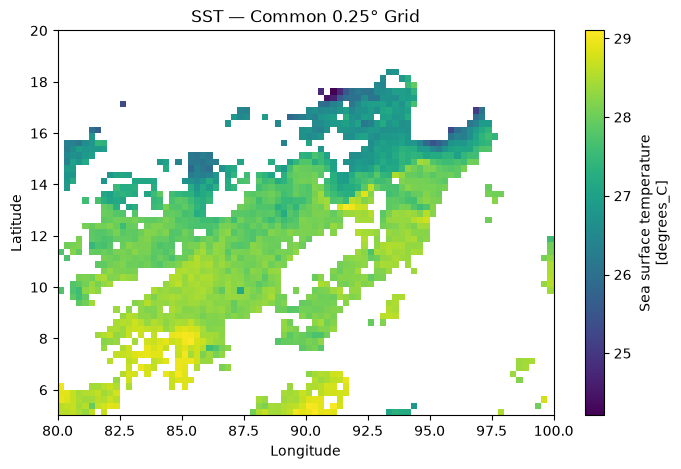

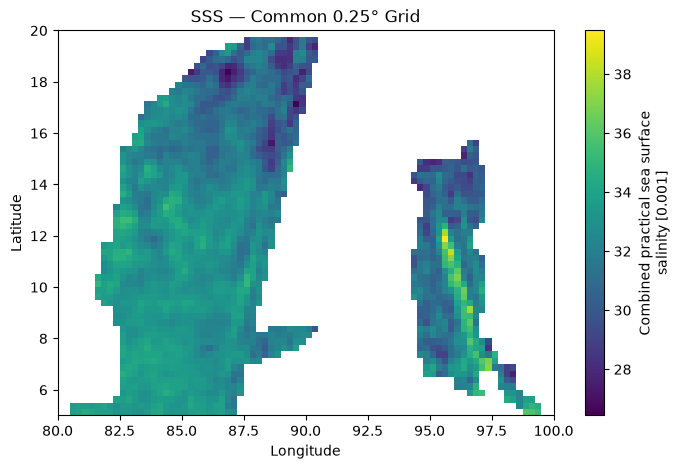

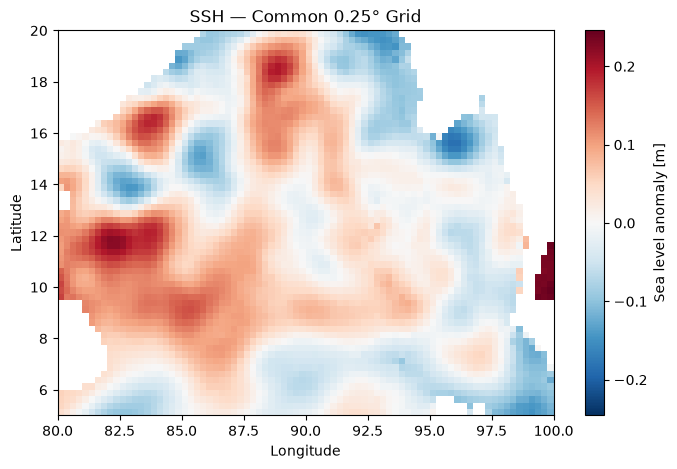

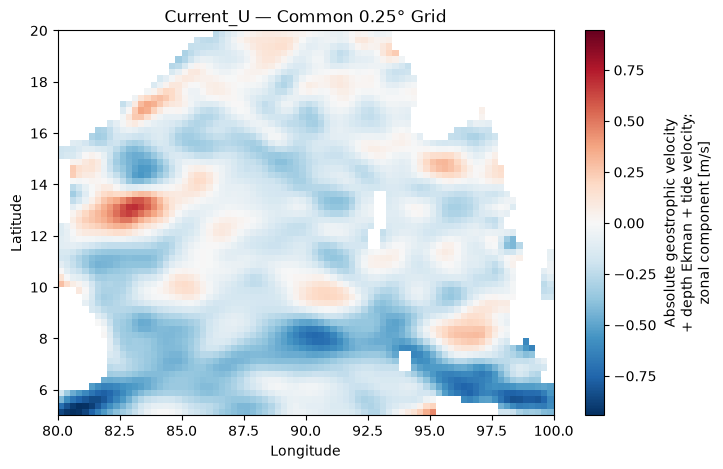

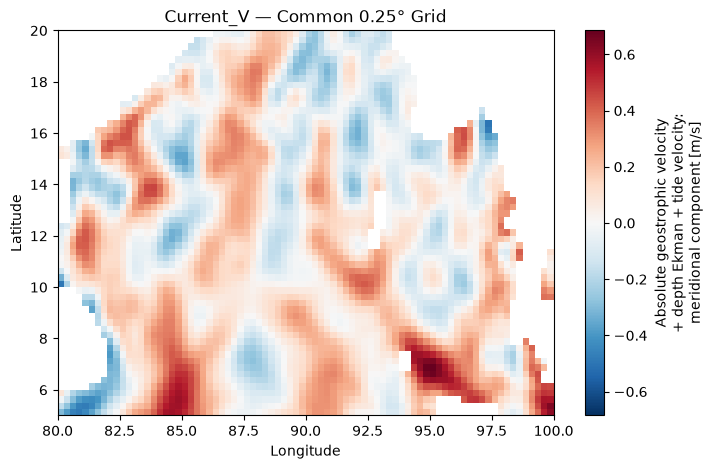

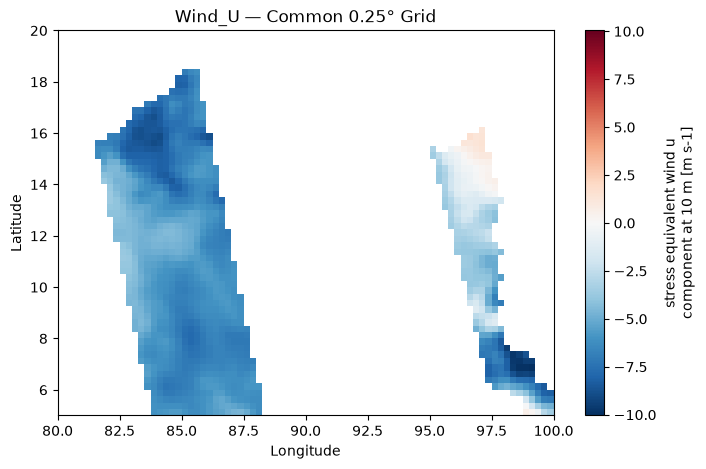

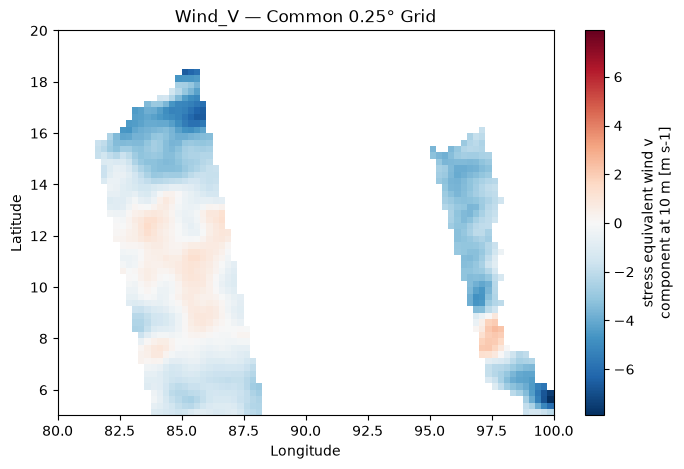

In [270]:
import matplotlib.pyplot as plt

variables = [
    "SST",
    "SSS",
    "SSH",
    "Current_U",
    "Current_V",
    "Wind_U",
    "Wind_V",
]

for var in variables:
    plt.figure(figsize=(8, 5))

    surface_common[var].isel(time=0).plot()

    plt.title(f"{var} — Common 0.25° Grid")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

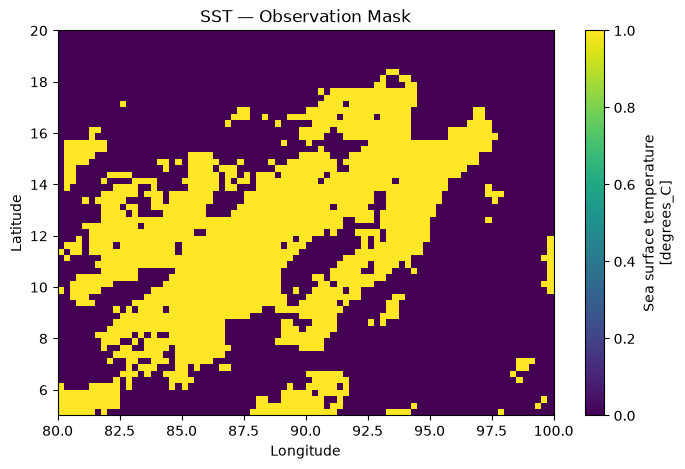

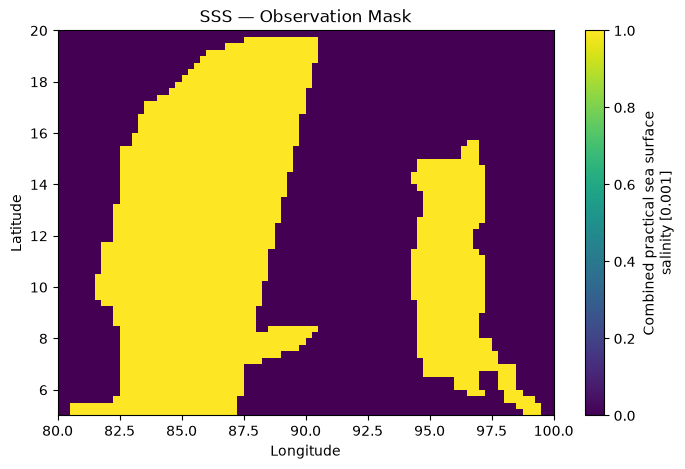

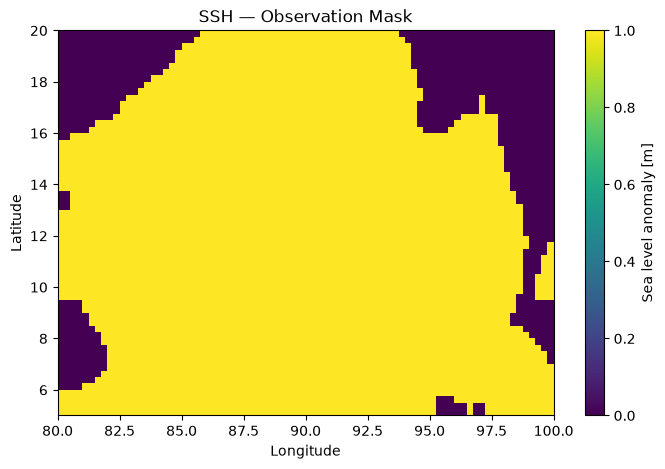

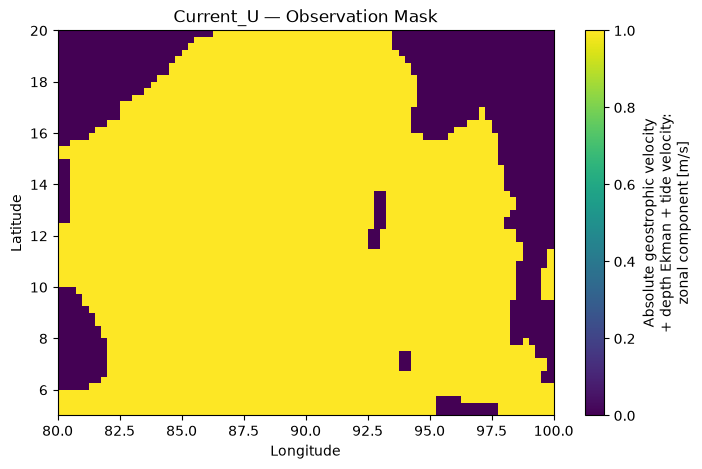

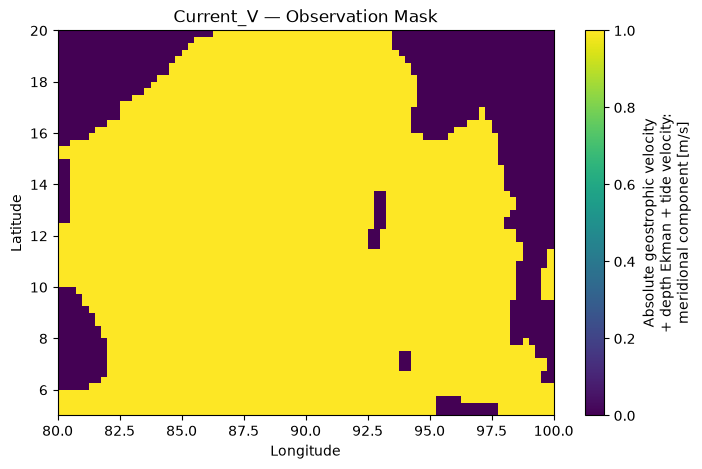

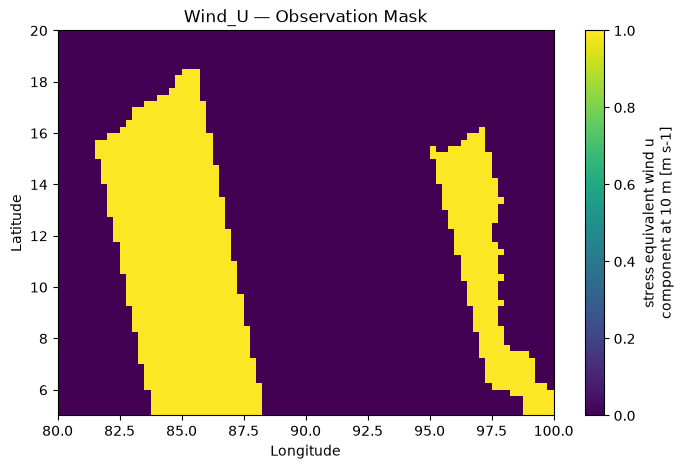

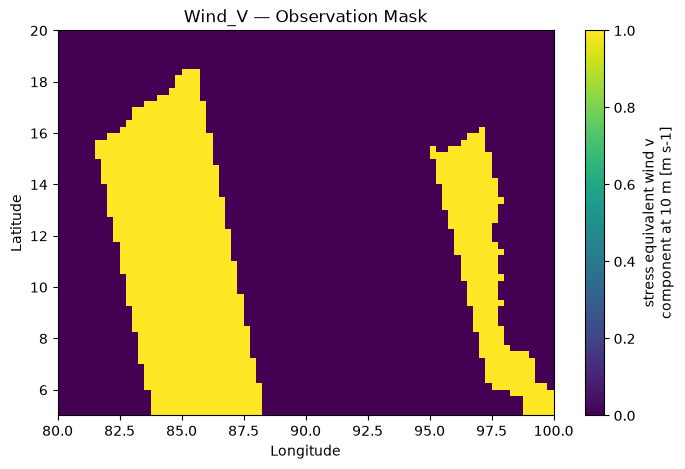

In [271]:
for var in variables:
    plt.figure(figsize=(8, 5))

    surface_common[var].isel(time=0).notnull().plot()

    plt.title(f"{var} — Observation Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

## Step 14 — Convert GLORYS to the 15 target depths

0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

In [272]:
# ============================================================
# Step 14 — GLORYS Vertical Interpolation
# ============================================================

target_depths = xr.DataArray(
    [0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
     200, 300, 500, 700, 1000],
    dims="depth",
    name="depth"
)

print(target_depths)

<xarray.DataArray 'depth' (depth: 15)> Size: 120B
array([   0,    5,   10,   20,   30,   50,   75,  100,  125,  150,  200,
        300,  500,  700, 1000])
Dimensions without coordinates: depth


14.2 Handle the 0-m target carefully

GLORYS starts at approximately:

0.494 m

not exactly 0 m.

We should not extrapolate from the 0.494-m level to 0 m.

For this prototype, use the shallowest GLORYS level as the 0-m proxy:

In [273]:
print("Original shallowest depth:",
      float(thetao_std.depth.values[0]))

print("Original deepest depth:",
      float(thetao_std.depth.values[-1])) #basically the shallowest one will be treated as 0m

Original shallowest depth: 0.49402499198913574
Original deepest depth: 1062.43994140625


In [274]:
thetao_for_interp = thetao_std.copy()

thetao_for_interp = thetao_for_interp.assign_coords(
    depth=xr.where(
        thetao_for_interp.depth == thetao_for_interp.depth[0],
        0,
        thetao_for_interp.depth
    )
)

In [275]:
#vertical interpolation
thetao_15depth = thetao_for_interp.interp(
    depth=target_depths
)

In [276]:
print(thetao_15depth)

<xarray.DataArray 'thetao' (time: 31, depth: 15, latitude: 181, longitude: 241)> Size: 162MB
array([[[[28.38670003, 28.39841913, 28.40647602, ..., 29.76003295,
          29.79445783, 29.91677602],
         [28.36252937, 28.37644581, 28.38816492, ..., 29.74684896,
          29.85891292, 30.13943906],
         [28.32151249, 28.33542893, 28.34861293, ..., 29.7541734 ,
          29.9446089 , 30.28519546],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[28.33679863, 28.34705285, 28.35437729, ..., 29.61381306,
          29.62910335, 29.7534368 ],
         [28.31551223, 28.3280093 , 28.33895044, ..., 29.61088328,
          29.6990497 , 29.96570076],
         [28.28030939, 28.29280646, 28.30379312, ..., 29.63

In [277]:
print("Target depths:")
print(thetao_15depth.depth.values)

Target depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


In [278]:
thetao_mean_profile = thetao_15depth.mean(
    dim=["time", "latitude", "longitude"],
    skipna=True
)

print(thetao_mean_profile)

<xarray.DataArray 'thetao' (depth: 15)> Size: 120B
array([27.57763992, 27.5466555 , 27.55135249, 27.62748265, 27.64868865,
       27.03246566, 24.64631737, 21.39086278, 18.51036665, 16.34707553,
       13.86205734, 11.67115606,  9.99188359,  8.54337128,  6.67813078])
Coordinates:
  * depth    (depth) int64 120B 0 5 10 20 30 50 75 ... 150 200 300 500 700 1000
Attributes:
    cell_methods:   area: mean
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    unit_long:      Degrees Celsius
    units:          degrees_C
    valid_max:      21306
    valid_min:      -32766


In [279]:
for depth in target_depths.values:
    da = thetao_15depth.sel(depth=depth)

    print(
        f"{depth:4.0f} m | "
        f"missing = {100 * float(da.isnull().mean()):.2f}%"
    )

   0 m | missing = 18.85%
   5 m | missing = 18.85%
  10 m | missing = 20.58%
  20 m | missing = 22.27%
  30 m | missing = 23.87%
  50 m | missing = 26.09%
  75 m | missing = 28.02%
 100 m | missing = 29.85%
 125 m | missing = 30.36%
 150 m | missing = 30.75%
 200 m | missing = 31.44%
 300 m | missing = 32.32%
 500 m | missing = 34.08%
 700 m | missing = 35.40%
1000 m | missing = 37.39%


## Step 15 — Regrid GLORYS horizontally

GLORYS native
181 × 241
      ↓
vertical interpolation
15 depths
      ↓
horizontal interpolation
60 × 80
      ↓
Y
(time, depth, latitude, longitude)

In [280]:
thetao_common = thetao_15depth.interp(
    latitude=common_lat,
    longitude=common_lon
)

In [281]:
print(thetao_common)

<xarray.DataArray 'thetao' (time: 31, depth: 15, latitude: 60, longitude: 80)> Size: 18MB
array([[[[28.36216315, 28.40519424, 28.42533646, ..., 29.40369884,
          29.72927029, 29.82613604],
         [28.25962095, 28.27793206, 28.32718893, ..., 29.39765617,
          29.57087923, 30.05758842],
         [28.54820398, 28.33341471, 28.27628406, ..., 29.21875667,
          29.49287392, 30.10318307],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[28.31588983, 28.35761639, 28.37866278, ..., 29.27018698,
          29.64148247, 29.68940275],
         [28.22297287, 28.24490067, 28.29559968, ..., 29.34211657,
          29.51804598, 29.96602458],
         [28.50884336, 28.30129888, 28.24471756, ..., 29.17849

In [282]:
print("Shape:", thetao_common.shape)
print("Depths:", thetao_common.depth.values)
print("Lat:", thetao_common.latitude.values[[0, -1]])
print("Lon:", thetao_common.longitude.values[[0, -1]])

Shape: (31, 15, 60, 80)
Depths: [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]
Lat: [ 5.125 19.875]
Lon: [80.125 99.875]


## Step 16 — Align everything and construct X/Y

X channels = 7
SST
SSS
SSH
Current_U
Current_V
Wind_U
Wind_V

Y depths = 15
0, 5, 10, 20, 30, 50, 75, 100, 125, 150,
200, 300, 500, 700, 1000 m

In [283]:
# ============================================================
# Step 16 — Align Surface Inputs and GLORYS Target
# ============================================================

surface_common, thetao_common = xr.align(
    surface_common,
    thetao_common,
    join="exact"
)

print("Surface dimensions:")
print(surface_common.sizes)

print("\nTarget dimensions:")
print(thetao_common.sizes)

Surface dimensions:
Frozen({'time': 31, 'latitude': 60, 'longitude': 80})

Target dimensions:
Frozen({'time': 31, 'depth': 15, 'latitude': 60, 'longitude': 80})


In [284]:
input_variables = [
    "SST",
    "SSS",
    "SSH",
    "Current_U",
    "Current_V",
    "Wind_U",
    "Wind_V",
]

X_da = xr.concat(
    [surface_common[var] for var in input_variables],
    dim="channel"
)

X_da = X_da.assign_coords(
    channel=input_variables
)

X_da.name = "surface_inputs"

print(X_da)

<xarray.DataArray 'surface_inputs' (channel: 7, time: 31, latitude: 60,
                                    longitude: 80)> Size: 8MB
array([[[[ 2.85843764e+01,  2.85662515e+01,  2.86475002e+01, ...,
                      nan,             nan,             nan],
         [ 2.85975000e+01,  2.86312513e+01,  2.86637507e+01, ...,
           2.80287554e+01,             nan,             nan],
         [ 2.89249990e+01,  2.88399992e+01,  2.86618734e+01, ...,
                      nan,  2.87406229e+01,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,             nan, ...,
                

In [285]:
Y_da = thetao_common.rename(
    "subsurface_temperature"
)

print(Y_da)

<xarray.DataArray 'subsurface_temperature' (time: 31, depth: 15, latitude: 60,
                                            longitude: 80)> Size: 18MB
array([[[[28.36216315, 28.40519424, 28.42533646, ..., 29.40369884,
          29.72927029, 29.82613604],
         [28.25962095, 28.27793206, 28.32718893, ..., 29.39765617,
          29.57087923, 30.05758842],
         [28.54820398, 28.33341471, 28.27628406, ..., 29.21875667,
          29.49287392, 30.10318307],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[28.31588983, 28.35761639, 28.37866278, ..., 29.27018698,
          29.64148247, 29.68940275],
         [28.22297287, 28.24490067, 28.29559968, ..., 29.34211657,
          29.51804598, 29.96602458],
  

In [286]:
X_mask = X_da.notnull()

X_mask.name = "surface_observation_mask"

print(X_mask)

<xarray.DataArray 'surface_observation_mask' (channel: 7, time: 31,
                                              latitude: 60, longitude: 80)> Size: 1MB
array([[[[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ..., False,  True, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[ True,  True,  True, ..., False, False, False],
         [False,  True,  True, ..., False, False, False],
  

In [287]:
Y_mask = Y_da.notnull()

Y_mask.name = "target_valid_mask"

In [288]:
X_da = X_da.transpose(
    "time",
    "channel",
    "latitude",
    "longitude"
)

X_mask = X_mask.transpose(
    "time",
    "channel",
    "latitude",
    "longitude"
)

print("X shape:", X_da.shape)
print("Mask shape:", X_mask.shape)

X shape: (31, 7, 60, 80)
Mask shape: (31, 7, 60, 80)


In [289]:
print("========== FINAL PROTOTYPE SHAPES ==========")

print("X:", X_da.shape)
print("Y:", Y_da.shape)
print("X mask:", X_mask.shape)
print("Y mask:", Y_mask.shape)

print("\nChannels:")
print(X_da.channel.values)

print("\nTarget depths:")
print(Y_da.depth.values)

========== FINAL PROTOTYPE SHAPES ==========
X: (31, 7, 60, 80)
Y: (31, 15, 60, 80)
X mask: (31, 7, 60, 80)
Y mask: (31, 15, 60, 80)

Channels:
['SST' 'SSS' 'SSH' 'Current_U' 'Current_V' 'Wind_U' 'Wind_V']

Target depths:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]


In [290]:
joint_input_mask = X_mask.all(dim="channel")

print(
    "Grid cells with all 7 inputs available:",
    int(joint_input_mask.sum())
)

print(
    "Total grid cells:",
    joint_input_mask.size
)

print(
    "Joint missing percentage:",
    100 * float((~joint_input_mask).mean())
)

Grid cells with all 7 inputs available: 8783
Total grid cells: 148800
Joint missing percentage: 94.09744623655914


Step 17 — Define the missing-input strategy

observed value → keep it
missing value  → replace with a neutral value
mask           → tell model whether it was observed


raw X
 ↓
QC
 ↓
common grid
 ↓
split train/validation/test
 ↓
calculate training statistics
 ↓
normalize
 ↓
fill missing normalized values with 0
 ↓
provide observation mask separately

# Step 17 — Missing-Input Strategy

The surface observations have substantially different spatial coverage.
On the one-day prototype, only approximately 10.08% of grid cells contain
simultaneous observations from all seven surface variables.

Discarding all grid cells with any missing input would therefore remove most
of the available spatial domain.

ANTARBODH therefore preserves missing observations using an explicit
observation-mask representation.

For each surface variable:

- observed values are retained;
- missing values remain NaN during the preprocessing stage;
- a binary observation mask is retained;
- missing values will later be replaced by zero only after training-set
  normalization;
- the corresponding mask will be supplied to the model so that zero-imputed
  values are distinguishable from genuine zero-valued observations.

This allows the model to use partially observed surface fields without
treating missing observations as physical measurements.

No target temperature values are imputed at this stage.

In [291]:
print(X_mask)

<xarray.DataArray 'surface_observation_mask' (time: 31, channel: 7,
                                              latitude: 60, longitude: 80)> Size: 1MB
array([[[[ True,  True,  True, ..., False, False, False],
         [ True,  True,  True, ...,  True, False, False],
         [ True,  True,  True, ..., False,  True, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[False, False,  True, ...,  True, False, False],
         [False, False,  True, ...,  True, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
  

In [292]:
for channel in X_mask.channel.values:
    mask = X_mask.sel(channel=channel)

    valid = int(mask.sum())
    total = mask.size
    coverage = 100 * valid / total

    print(
        f"{channel:12s} | "
        f"valid = {valid:4d} | "
        f"coverage = {coverage:.2f}%"
    )

SST          | valid = 81466 | coverage = 54.75%
SSS          | valid = 33629 | coverage = 22.60%
SSH          | valid = 122264 | coverage = 82.17%
Current_U    | valid = 117273 | coverage = 78.81%
Current_V    | valid = 117273 | coverage = 78.81%
Wind_U       | valid = 37115 | coverage = 24.94%
Wind_V       | valid = 37115 | coverage = 24.94%


In [293]:
value_channels = X_da

mask_channels = X_mask.astype(np.float32) #convert true to 1,false to 0

mask_channels = mask_channels.assign_coords(
    channel=[f"{c}_mask" for c in X_da.channel.values]
)

X_14 = xr.concat(
    [value_channels, mask_channels],
    dim="channel"
)

print(X_14)

<xarray.DataArray 'surface_inputs' (time: 31, channel: 14, latitude: 60,
                                    longitude: 80)> Size: 17MB
array([[[[ 2.85843764e+01,  2.85662515e+01,  2.86475002e+01, ...,
                      nan,             nan,             nan],
         [ 2.85975000e+01,  2.86312513e+01,  2.86637507e+01, ...,
           2.80287554e+01,             nan,             nan],
         [ 2.89249990e+01,  2.88399992e+01,  2.86618734e+01, ...,
                      nan,  2.87406229e+01,             nan],
         ...,
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan],
         [            nan,             nan,             nan, ...,
                      nan,             nan,             nan]],

        [[            nan,             nan,  3.37656857e+01, ...,
           3.5

split time before normalization

This is where we need to start thinking about your eventual 5-year dataset.

Never calculate normalization statistics using the entire 5-year dataset before splitting.

That would leak information from validation/test periods into training.

Eventually:
```mermaid
2020–2023 → training
2024      → validation
2025      → test
```
or another chronological split you choose.

Then:
```mermaid
training data
      ↓
mean/std
      ↓
normalize train
normalize validation
normalize test
```


Validation and test use training statistics only.

For the current one-day prototype, we can't meaningfully create a realistic multi-year temporal split because we have only one day.

So don't calculate the final normalization statistics yet.

In [294]:
print("========== TARGET COVERAGE ==========")

for depth in Y_da.depth.values:
    target = Y_da.sel(depth=depth)

    valid = int(target.notnull().sum())
    total = target.size
    coverage = 100 * valid / total

    print(
        f"{depth:4.0f} m | "
        f"valid = {valid:4d} | "
        f"coverage = {coverage:.2f}%"
    )

========== TARGET COVERAGE ==========
   0 m | valid = 119288 | coverage = 80.17%
   5 m | valid = 119288 | coverage = 80.17%
  10 m | valid = 116653 | coverage = 78.40%
  20 m | valid = 114049 | coverage = 76.65%
  30 m | valid = 111693 | coverage = 75.06%
  50 m | valid = 108438 | coverage = 72.88%
  75 m | valid = 105307 | coverage = 70.77%
 100 m | valid = 102889 | coverage = 69.15%
 125 m | valid = 102238 | coverage = 68.71%
 150 m | valid = 101742 | coverage = 68.38%
 200 m | valid = 100471 | coverage = 67.52%
 300 m | valid = 99417 | coverage = 66.81%
 500 m | valid = 96751 | coverage = 65.02%
 700 m | valid = 94364 | coverage = 63.42%
1000 m | valid = 91202 | coverage = 61.29%


In [295]:
print(
    "Any valid target:",
    bool(Y_mask.any())
)

Any valid target: True


## Step 29 — Finalize the prototype dataset

Before normalization, let's establish one important principle:

We do not need every target depth to be valid at every grid cell.

The target mask Y_mask will tell us which target values are available.

For training, later, the loss can be computed only over valid target locations.

So we preserve:

Y
+
Y_mask

rather than filling missing GLORYS temperatures.

In [296]:
# ============================================================
# Step 29 — Create ML-ready Prototype Dataset
# ============================================================

processed = xr.Dataset(
    {
        "X": X_da,
        "X_mask": X_mask.astype(np.int8),
        "Y": Y_da,
        "Y_mask": Y_mask.astype(np.int8),
    }
)

processed.attrs["project"] = "ANTARBODH"
processed.attrs["description"] = (
    "One-day prototype of surface observations and "
    "GLORYS-derived subsurface temperature targets"
)
processed.attrs["region"] = "Bay of Bengal prototype"
processed.attrs["grid_resolution"] = "0.25 degree"
processed.attrs["input_channels"] = 7
processed.attrs["target_depths"] = (
    "0, 5, 10, 20, 30, 50, 75, 100, 125, "
    "150, 200, 300, 500, 700, 1000 m"
)

print(processed)

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 31, latitude: 60, longitude: 80, channel: 7, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
  * channel    (channel) <U9 252B 'SST' 'SSS' 'SSH' ... 'Wind_U' 'Wind_V'
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
Data variables:
    X          (time, channel, latitude, longitude) float64 8MB 28.58 ... nan
    X_mask     (time, channel, latitude, longitude) int8 1MB 1 1 1 1 ... 0 0 0 0
    Y          (time, depth, latitude, longitude) float64 18MB 28.36 ... nan
    Y_mask     (time, depth, latitude, longitude) int8 2MB 1 1 1 1 1 ... 0 0 0 0
Attributes:
    project:          ANTARBODH
    description:      One-day prototype of surface observations and GLORYS-de...
    region:           Bay of Ben

In [297]:
print("========== FINAL DIMENSION CHECK ==========")

print("X:")
print(processed["X"].dims, processed["X"].shape)

print("\nX mask:")
print(processed["X_mask"].dims, processed["X_mask"].shape)

print("\nY:")
print(processed["Y"].dims, processed["Y"].shape)

print("\nY mask:")
print(processed["Y_mask"].dims, processed["Y_mask"].shape)

========== FINAL DIMENSION CHECK ==========
X:
('time', 'channel', 'latitude', 'longitude') (31, 7, 60, 80)

X mask:
('time', 'channel', 'latitude', 'longitude') (31, 7, 60, 80)

Y:
('time', 'depth', 'latitude', 'longitude') (31, 15, 60, 80)

Y mask:
('time', 'depth', 'latitude', 'longitude') (31, 15, 60, 80)


In [298]:
print("X NaNs:", int(processed["X"].isnull().sum()))
print("Y NaNs:", int(processed["Y"].isnull().sum()))

X NaNs: 495465
Y NaNs: 648210


In [299]:
for name in ["X", "Y"]:
    values = processed[name]

    print(
        name,
        "has Inf:",
        bool(np.isinf(values.values).any())
    )

X has Inf: False
Y has Inf: False


In [300]:
x_check = processed["X"].notnull()

print(
    "X mask correct:",
    bool((x_check == processed["X_mask"].astype(bool)).all())
)

X mask correct: True


In [301]:
y_check = processed["Y"].notnull()

print(
    "Y mask correct:",
    bool((y_check == processed["Y_mask"].astype(bool)).all())
)

Y mask correct: True


In [302]:
print("Latitude:")
print(processed.latitude.values[[0, -1]])

print("\nLongitude:")
print(processed.longitude.values[[0, -1]])

print("\nDepth:")
print(processed.depth.values)

print("\nChannels:")
print(processed.channel.values)

Latitude:
[ 5.125 19.875]

Longitude:
[80.125 99.875]

Depth:
[   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]

Channels:
['SST' 'SSS' 'SSH' 'Current_U' 'Current_V' 'Wind_U' 'Wind_V']


In [305]:
from pathlib import Path

output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "antarbodh_prototype_one_month.nc"

processed.to_netcdf(
    output_path,
    format="NETCDF4",
    engine="netcdf4",
    encoding={
        "X": {"zlib": True, "complevel": 4},
        "X_mask": {"zlib": True, "complevel": 4},
        "Y": {"zlib": True, "complevel": 4},
        "Y_mask": {"zlib": True, "complevel": 4},
    }
)

print("Saved:", output_path)

Saved: data/processed/antarbodh_prototype_one_month.nc


In [306]:
check = xr.open_dataset(output_path)

print(check)

<xarray.Dataset> Size: 29MB
Dimensions:    (time: 31, channel: 7, latitude: 60, longitude: 80, depth: 15)
Coordinates:
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
  * channel    (channel) <U9 252B 'SST' 'SSS' 'SSH' ... 'Wind_U' 'Wind_V'
  * latitude   (latitude) float64 480B 5.125 5.375 5.625 ... 19.38 19.62 19.88
  * longitude  (longitude) float64 640B 80.12 80.38 80.62 ... 99.38 99.62 99.88
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
Data variables:
    X          (time, channel, latitude, longitude) float64 8MB ...
    X_mask     (time, channel, latitude, longitude) int8 1MB ...
    Y          (time, depth, latitude, longitude) float64 18MB ...
    Y_mask     (time, depth, latitude, longitude) int8 2MB ...
Attributes:
    project:          ANTARBODH
    description:      One-day prototype of surface observations and GLORYS-de...
    region:           Bay of Bengal prototype
    grid_resolution:  0.25 degree
    in

In [168]:
# ============================================================
# Step 35 — Temporal Train / Validation / Test Split
# ============================================================

train_end = np.datetime64("2023-12-31")
val_end = np.datetime64("2024-12-31")

train_mask = processed.time <= train_end
val_mask = (processed.time > train_end) & (processed.time <= val_end)
test_mask = processed.time > val_end

print("Train:", processed.time.values[train_mask])
print("Validation:", processed.time.values[val_mask])
print("Test:", processed.time.values[test_mask])

Train: ['2020-01-01T00:00:00.000000000']
Validation: []
Test: []
